# Семинар: Предсказание уровня гемоглобина по изображениям ногтей с помощью Deep Learning

**Датасет:** [Yakimov et al., Scientific Data, 2024](https://www.nature.com/articles/s41597-024-03895-9)
| **GitHub:** [biophotonics-msu/photo-haemoglobin](https://github.com/biophotonics-msu/photo-haemoglobin)

---

### Цель семинара
- Познакомиться с задачей **неинвазивной диагностики** анемии по фотографии
- Пройти весь путь от сырых данных до обученной модели
- Сравнить классический Machine Learning и Deep Learning
- Научиться интерпретировать результаты в клиническом контексте

### План семинара
| Этап | Описание | Время |
|------|----------|-------|
| 1. Введение | Клинический контекст, датасет | 10 мин |
| 2. EDA | Исследование данных, визуализации | 20 мин |
| 3. Feature Engineering | Извлечение признаков из изображений | 15 мин |
| 4. Classical ML | ElasticNet регрессия | 20 мин |
| 5. Deep Learning | Transfer Learning с ResNet18 | 30 мин |
| 6. Сравнение | Анализ результатов, классификация | 15 мин |

## Введение: Клинический контекст

### Что такое гемоглобин?

**Гемоглобин (Hb)** — белок в эритроцитах, переносящий кислород от лёгких к тканям.
Нормальные значения:
- Мужчины: **130–170 г/л**
- Женщины: **120–150 г/л**

### Что такое анемия?

**Анемия** — снижение уровня гемоглобина ниже нормы. Это одно из самых распространённых
заболеваний в мире:
- 🌍 **~1.8 млрд** человек страдают анемией (ВОЗ)
- Основные причины: дефицит железа, витамина B12, хронические заболевания
- Симптомы: слабость, бледность, одышка, головокружение

### Почему ногти?

Ногтевая пластина — полупрозрачная ткань, через которую видна **капиллярная сеть**.
Гемоглобин — основной **хромофор** (поглотитель света) в этой области.
При анемии ногти становятся бледнее, потому что меньше гемоглобина поглощает свет.

> **Ключевая идея:** Если цвет ногтя зависит от уровня Hb, то можно обучить модель
> предсказывать Hb по RGB-значениям пикселей фотографии ногтя.

### Зачем неинвазивная диагностика?

| | Стандартный анализ крови | Фото ногтя |
|---|---|---|
| Инвазивность | Забор крови из вены | Нет |
| Оборудование | Лаборатория, гематологический анализатор | Смартфон |
| Время | Часы — дни | Секунды |
| Доступность | Ограничена | Везде |
| Точность | Высокая (золотой стандарт) | Пока ниже |

### О датасете

Датасет собран исследователями из МГУ (кафедра биофотоники):

| Параметр | Значение |
|----------|----------|
| Пациентов | 250 |
| Пол | 128 муж. / 122 жен. |
| Возраст | 18–95 лет (среднее 56 ± 20) |
| Hb диапазон | 44–169 г/л |
| Камера | Logitech C615 (USB) |
| Освещение | Белый LED, ~7300 K |
| Условия | Изолированный бокс 40×40×20 см |

Для каждого пациента:
- RGB-фото кисти руки (`.jpg`)
- Координаты областей ногтей (3 пальца) и кожи (3 участка) — **bounding boxes**
- Уровень Hb (референс — сертифицированный гематологический анализатор)

## 1. Подготовка окружения

Начнём с установки и импорта всех необходимых библиотек.

In [ ]:
# Установка библиотек (для Google Colab)
!pip install -q scikit-image tqdm

### Что мы используем?

| Библиотека | Для чего |
|------------|----------|
| `numpy` | Работа с числовыми массивами |
| `pandas` | Таблицы с данными (DataFrame) |
| `matplotlib` | Визуализации и графики |
| `scikit-image` | Загрузка и обработка изображений |
| `scikit-learn` | Классические ML-алгоритмы |
| `torch` (PyTorch) | Deep Learning фреймворк |
| `torchvision` | Предобученные нейросети и трансформации изображений |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import glob
from collections import defaultdict
from tqdm import tqdm

import skimage.io as skio
import matplotlib.patches as mpatches
import scipy.stats as stats

import sklearn.preprocessing
import sklearn.model_selection
import sklearn.pipeline
import sklearn.linear_model
import sklearn.metrics

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

# Проверяем, доступен ли GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('GPU не найден. Deep Learning будет работать медленнее.')
    print('В Colab: Runtime -> Change runtime type -> GPU')

Device: cuda
GPU: NVIDIA GeForce RTX 4090 Laptop GPU


## 2. Загрузка и исследование данных (EDA)

**EDA (Exploratory Data Analysis)** — первый и важнейший шаг в любом ML-проекте.
Прежде чем строить модели, нужно **понять данные**: их структуру, распределения, возможные проблемы.

### Скачивание датасета

In [ ]:
DATA_DIR = 'data'
PHOTO_DIR = os.path.join(DATA_DIR, 'photo')

if not os.path.exists(PHOTO_DIR):
    print("Скачиваем датасет с Figshare (~87 MB)...")
    os.makedirs(DATA_DIR, exist_ok=True)

    # Прямая ссылка на файл (получена через Figshare API)
    !wget -q --show-progress "https://ndownloader.figshare.com/files/49504041" -O dataset.zip
    !unzip -q -o dataset.zip -d {DATA_DIR}
    !rm -f dataset.zip

    # Handle potential nested directory structure
    if not os.path.exists(os.path.join(DATA_DIR, 'metadata.csv')):
        csv_files = glob.glob(os.path.join(DATA_DIR, '**', 'metadata.csv'), recursive=True)
        if csv_files:
            nested = os.path.dirname(csv_files[0])
            !mv {nested}/* {DATA_DIR}/
            print(f"Файлы перемещены из {nested}")
    print("Готово!")
else:
    print("Данные уже загружены.")

# Проверяем структуру
print(f"\nСодержимое {DATA_DIR}/:")
for f in sorted(os.listdir(DATA_DIR)):
    print(f"  {f}")
if os.path.exists(PHOTO_DIR):
    n_photos = len([f for f in os.listdir(PHOTO_DIR) if f.endswith('.jpg')])
    print(f"\nФотографий в photo/: {n_photos}")

Данные уже загружены.

Содержимое data/:
  metadata.csv
  photo

Фотографий в photo/: 251


### Загрузка метаданных

Метаданные хранятся в файле `metadata.csv`. Посмотрим, что там:

In [ ]:
metadata = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))

# Bounding boxes хранятся как строки JSON — преобразуем в списки
metadata['NAIL_BOUNDING_BOXES'] = metadata['NAIL_BOUNDING_BOXES'].apply(json.loads)
metadata['SKIN_BOUNDING_BOXES'] = metadata['SKIN_BOUNDING_BOXES'].apply(json.loads)

print(f"Размер таблицы: {metadata.shape[0]} строк, {metadata.shape[1]} столбцов")
print(f"\nСтолбцы: {list(metadata.columns)}")
print(f"\nПервые 5 строк:")
metadata.head()

Размер таблицы: 250 строк, 5 столбцов

Столбцы: ['PATIENT_ID', 'MEASUREMENT_DATE', 'HB_LEVEL_GperL', 'NAIL_BOUNDING_BOXES', 'SKIN_BOUNDING_BOXES']

Первые 5 строк:


,PATIENT_ID,MEASUREMENT_DATE,HB_LEVEL_GperL,NAIL_BOUNDING_BOXES,SKIN_BOUNDING_BOXES
0,1,14b0293a34344cc4fba0fa39d5370c52,134.0,"[[251, 447, 302, 505], [123, 429, 183, 483], [...","[[267, 586, 324, 627], [148, 556, 200, 614], [..."
1,2,14b0293a34344cc4fba0fa39d5370c52,108.0,"[[236, 503, 281, 556], [148, 457, 195, 514], [...","[[252, 612, 294, 647], [162, 585, 212, 632], [..."
2,5,14b0293a34344cc4fba0fa39d5370c52,84.0,"[[244, 508, 277, 562], [183, 448, 220, 505], [...","[[264, 629, 303, 662], [193, 584, 232, 619], [..."
3,6,14b0293a34344cc4fba0fa39d5370c52,138.0,"[[311, 456, 363, 521], [182, 408, 237, 471], [...","[[318, 609, 380, 650], [189, 562, 245, 616], [..."
4,7,14b0293a34344cc4fba0fa39d5370c52,119.0,"[[29, 513, 78, 556], [119, 435, 165, 479], [18...","[[29, 635, 79, 678], [117, 564, 175, 615], [20..."


### Что содержит таблица?

| Столбец | Описание |
|---------|----------|
| `PATIENT_ID` | Уникальный идентификатор пациента |
| `MEASUREMENT_DATE` | Дата измерения |
| `HB_LEVEL_GperL` | Уровень гемоглобина (г/л) — **это наша целевая переменная (target)** |
| `NAIL_BOUNDING_BOXES` | Координаты рамок вокруг ногтей `[top, left, bottom, right]` |
| `SKIN_BOUNDING_BOXES` | Координаты рамок вокруг участков кожи |

> **Bounding box** — прямоугольная рамка, задающая координаты интересующей области на изображении.
> Формат: `[верхний_край, левый_край, нижний_край, правый_край]` в пикселях.

### Распределение гемоглобина

Посмотрим, как распределён уровень Hb в нашем датасете.
Это важно для понимания: достаточно ли у нас примеров с анемией?

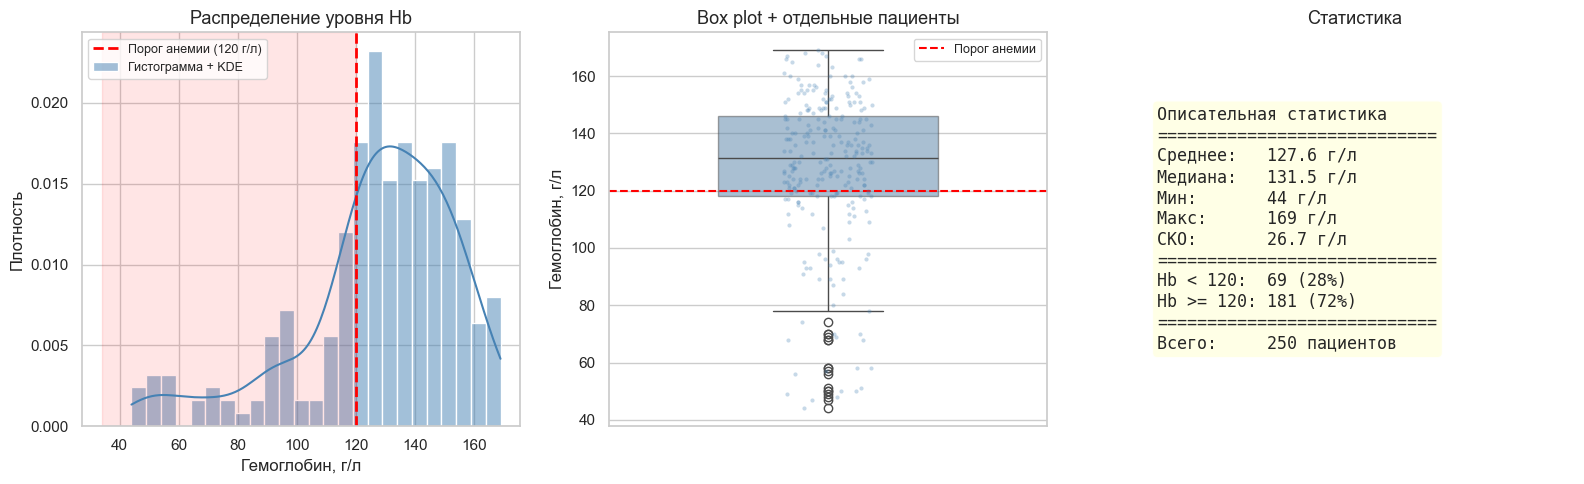

In [ ]:
target = metadata['HB_LEVEL_GperL']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Гистограмма с KDE — одна строка вместо ручного KDE
sns.histplot(target, bins=25, kde=True, color='steelblue', edgecolor='white',
             stat='density', ax=axes[0], label='Гистограмма + KDE')
axes[0].axvline(x=120, color='red', linestyle='--', linewidth=2, label='Порог анемии (120 г/л)')
axes[0].axvspan(target.min() - 10, 120, alpha=0.1, color='red')
axes[0].set_xlabel('Гемоглобин, г/л', fontsize=12)
axes[0].set_ylabel('Плотность', fontsize=12)
axes[0].set_title('Распределение уровня Hb', fontsize=13)
axes[0].legend(fontsize=9)

# 2. Box plot + strip plot — seaborn рисует оба сразу
sns.boxplot(y=target, color='steelblue', width=0.5, ax=axes[1],
            boxprops=dict(alpha=0.5))
sns.stripplot(y=target, color='steelblue', alpha=0.3, size=3, jitter=True, ax=axes[1])
axes[1].axhline(y=120, color='red', linestyle='--', linewidth=1.5, label='Порог анемии')
axes[1].set_ylabel('Гемоглобин, г/л', fontsize=12)
axes[1].set_title('Box plot + отдельные пациенты', fontsize=13)
axes[1].legend(fontsize=9)

# 3. Описательная статистика
anemia_count = (target < 120).sum()
normal_count = (target >= 120).sum()
txt = f"""Описательная статистика
{'='*28}
Среднее:   {target.mean():.1f} г/л
Медиана:   {target.median():.1f} г/л
Мин:       {target.min():.0f} г/л
Макс:      {target.max():.0f} г/л
СКО:       {target.std():.1f} г/л
{'='*28}
Hb < 120:  {anemia_count} ({anemia_count/len(target):.0%})
Hb >= 120: {normal_count} ({normal_count/len(target):.0%})
{'='*28}
Всего:     {len(target)} пациентов"""
axes[2].text(0.05, 0.5, txt, transform=axes[2].transAxes,
             fontsize=12, va='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[2].axis('off')
axes[2].set_title('Статистика', fontsize=13)

plt.tight_layout()
plt.show()

> **Что мы видим?**
> - Распределение Hb близко к нормальному, но смещено вправо (больше здоровых пациентов)
> - Пациентов с анемией (Hb < 120) меньше — **дисбаланс классов**, с которым мы будем бороться позже
> - Есть пациенты с очень низким Hb (~44 г/л) — тяжёлая анемия

### Дополнительный анализ Hb

Посмотрим на распределение гемоглобина подробнее: каждый пациент отдельно, кумулятивная функция распределения и клинические категории анемии.

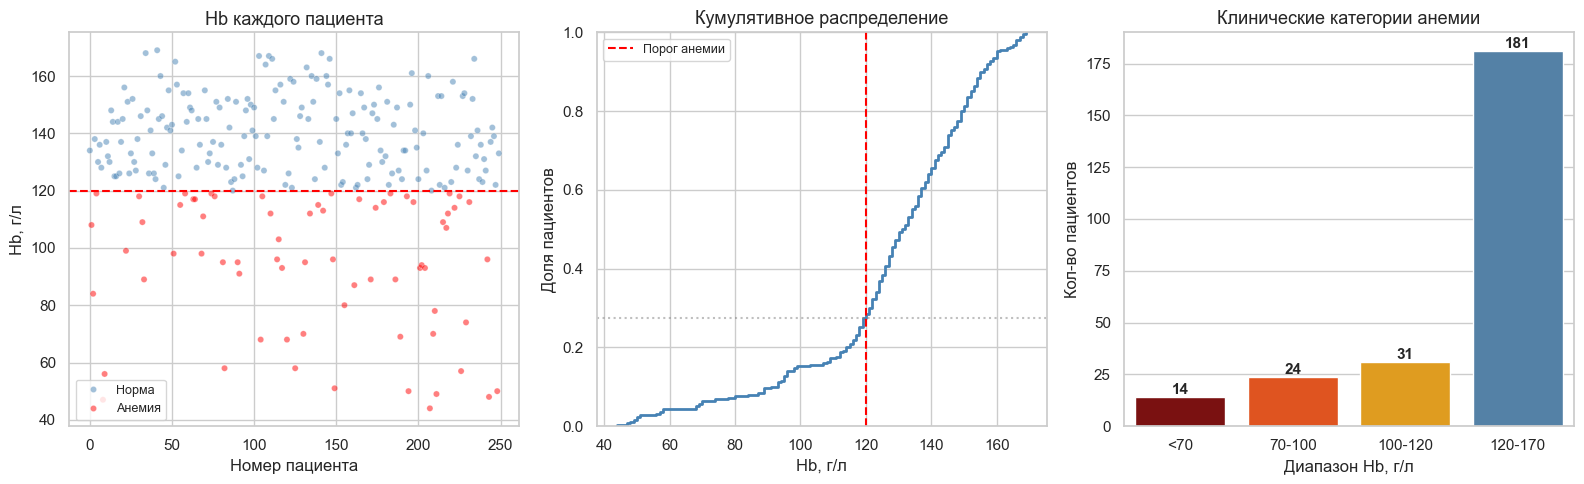

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Hb каждого пациента (scatter с цветом по порогу анемии)
hb_df = pd.DataFrame({'idx': range(len(target)), 'Hb': target.values,
                       'Статус': ['Анемия' if hb < 120 else 'Норма' for hb in target]})
sns.scatterplot(data=hb_df, x='idx', y='Hb', hue='Статус',
                palette={'Анемия': 'red', 'Норма': 'steelblue'},
                alpha=0.5, s=20, ax=axes[0])
axes[0].axhline(y=120, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Номер пациента', fontsize=12)
axes[0].set_ylabel('Hb, г/л', fontsize=12)
axes[0].set_title('Hb каждого пациента', fontsize=13)
axes[0].legend(fontsize=9)

# 2. Кумулятивное распределение (ECDF)
sns.ecdfplot(data=target, color='steelblue', linewidth=2, ax=axes[1])
axes[1].axvline(x=120, color='red', linestyle='--', label='Порог анемии')
axes[1].axhline(y=(target < 120).mean(), color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Hb, г/л', fontsize=12)
axes[1].set_ylabel('Доля пациентов', fontsize=12)
axes[1].set_title('Кумулятивное распределение', fontsize=13)
axes[1].legend(fontsize=9)

# 3. Клинические категории анемии
categories = ['<70', '70-100', '100-120', '120-170']
counts = [
    (target < 70).sum(),
    ((target >= 70) & (target < 100)).sum(),
    ((target >= 100) & (target < 120)).sum(),
    (target >= 120).sum()
]
cat_df = pd.DataFrame({'Категория': categories, 'Кол-во': counts})
sns.barplot(data=cat_df, x='Категория', y='Кол-во',
            palette=['darkred', 'orangered', 'orange', 'steelblue'],
            edgecolor='white', ax=axes[2])
for container in axes[2].containers:
    axes[2].bar_label(container, fontsize=11, fontweight='bold')
axes[2].set_xlabel('Диапазон Hb, г/л', fontsize=12)
axes[2].set_ylabel('Кол-во пациентов', fontsize=12)
axes[2].set_title('Клинические категории анемии', fontsize=13)

plt.tight_layout()
plt.show()


## 3. Визуализация изображений

### Как устроено цифровое изображение?

Каждое цифровое фото — это таблица чисел. Цветное изображение имеет **3 канала**:
- **R (Red)** — красный
- **G (Green)** — зелёный
- **B (Blue)** — синий

Каждый пиксель описывается тремя числами от 0 до 255.
Например, `(255, 0, 0)` — чистый красный, `(255, 255, 255)` — белый, `(0, 0, 0)` — чёрный.

> **Почему это важно?** Гемоглобин поглощает свет преимущественно в зелёном и синем диапазоне.
> Поэтому при анемии (мало Hb) ногти выглядят бледнее — меньше поглощения, больше отражённого света во всех каналах.

### Примеры изображений с bounding boxes

Для каждого пациента на фотографии руки размечены области:
- 🔴 **Красные рамки** — ногтевые пластины (3 пальца: указательный, средний, безымянный)
- 🔵 **Синие рамки** — участки кожи на фалангах пальцев

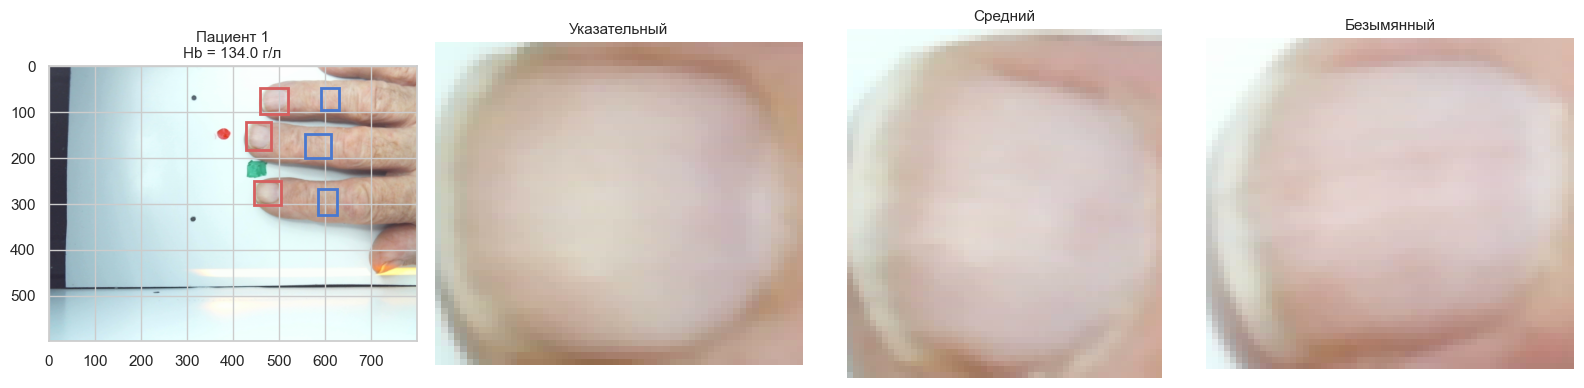

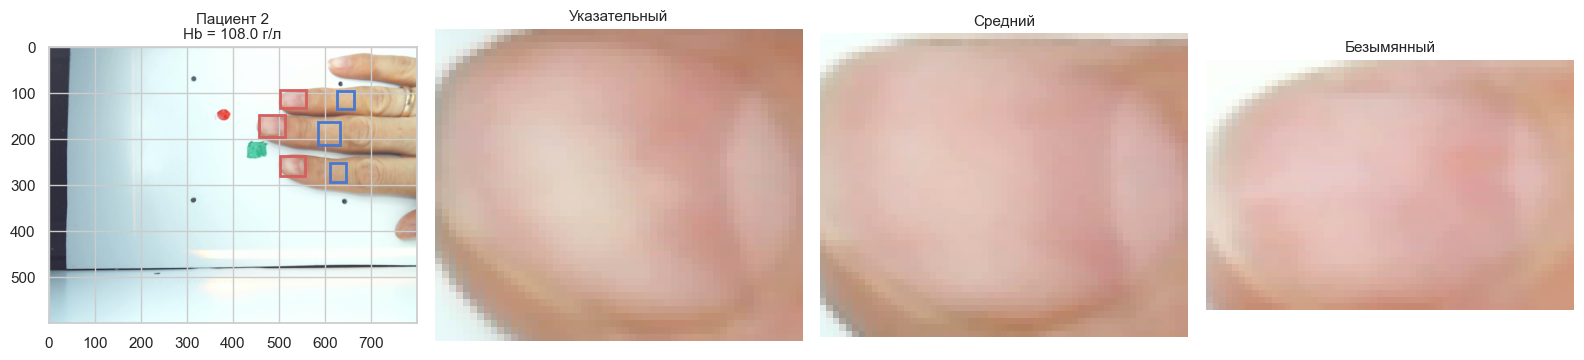

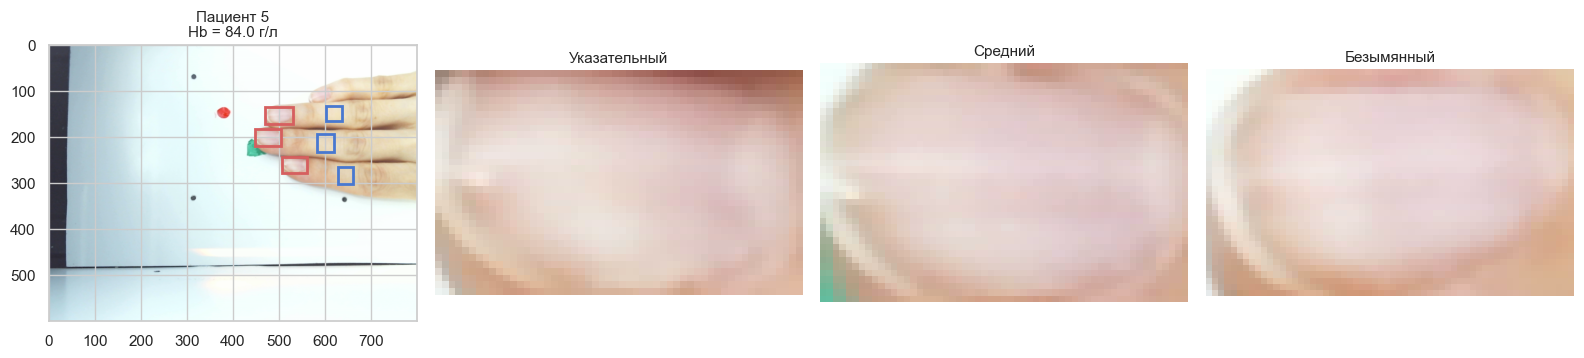

In [ ]:
image_folder = os.path.join(DATA_DIR, 'photo')
N_SHOW = 3

for j, (_, row) in enumerate(metadata.iterrows()):
    if j >= N_SHOW:
        break

    img = skio.imread(os.path.join(image_folder, f'{row.PATIENT_ID}.jpg'))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Full image with bboxes
    axes[0].imshow(img)
    axes[0].set_title(f'Пациент {row.PATIENT_ID}\nHb = {row.HB_LEVEL_GperL} г/л', fontsize=11)
    for color, bboxes in zip(['r', 'b'], [row.NAIL_BOUNDING_BOXES, row.SKIN_BOUNDING_BOXES]):
        for top, left, bot, right in bboxes:
            rect = mpatches.Rectangle((left, top), right - left, bot - top,
                                      fill=False, color=color, linewidth=2)
            axes[0].add_patch(rect)

    # Nail crops
    finger_names = ['Указательный', 'Средний', 'Безымянный']
    for i, (top, left, bot, right) in enumerate(row.NAIL_BOUNDING_BOXES):
        axes[i + 1].imshow(img[top:bot, left:right])
        axes[i + 1].set_title(f'{finger_names[i]}', fontsize=11)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

### RGB-каналы ногтевой пластины

Посмотрим, как выглядят отдельные цветовые каналы ногтя.
Это поможет понять, какая информация содержится в каждом канале.

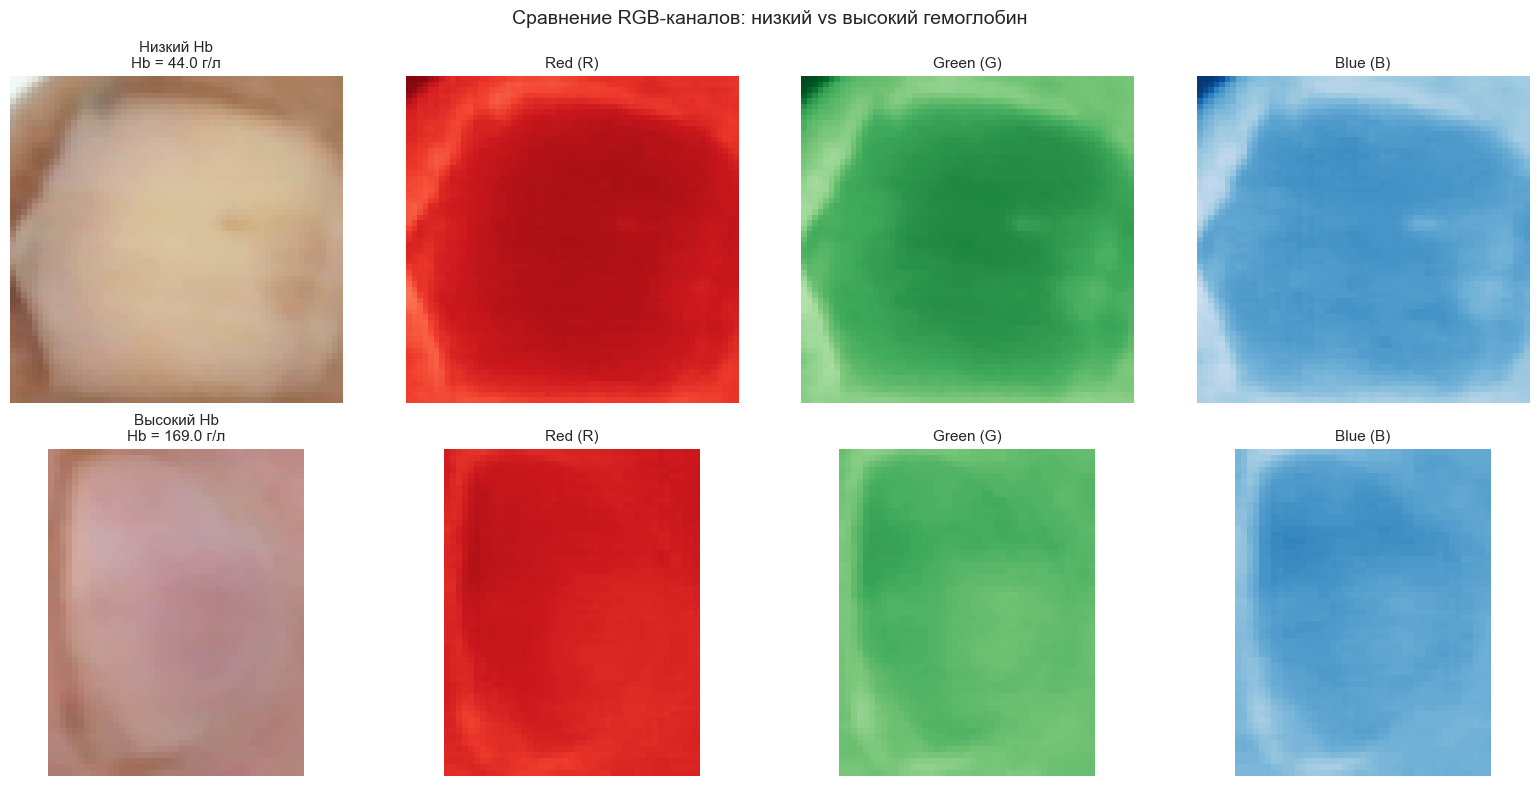

In [ ]:
# Take one example with low Hb and one with high Hb
low_hb_idx = target.idxmin()  # patient with lowest Hb
high_hb_idx = target.idxmax()  # patient with highest Hb

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row_idx, (pat_idx, label) in enumerate([(low_hb_idx, 'Низкий Hb'), (high_hb_idx, 'Высокий Hb')]):
    row_data = metadata.loc[pat_idx]
    img = skio.imread(os.path.join(image_folder, f'{row_data.PATIENT_ID}.jpg'))
    top, left, bot, right = row_data.NAIL_BOUNDING_BOXES[1]  # middle finger
    nail = img[top:bot, left:right]

    # Original
    axes[row_idx, 0].imshow(nail)
    axes[row_idx, 0].set_title(f'{label}\nHb = {row_data.HB_LEVEL_GperL} г/л', fontsize=11)
    axes[row_idx, 0].axis('off')

    # R, G, B channels
    channel_names = ['Red (R)', 'Green (G)', 'Blue (B)']
    cmaps = ['Reds', 'Greens', 'Blues']
    for ch in range(3):
        axes[row_idx, ch + 1].imshow(nail[:, :, ch], cmap=cmaps[ch], vmin=0, vmax=255)
        axes[row_idx, ch + 1].set_title(f'{channel_names[ch]}', fontsize=11)
        axes[row_idx, ch + 1].axis('off')

plt.suptitle('Сравнение RGB-каналов: низкий vs высокий гемоглобин', fontsize=14)
plt.tight_layout()
plt.show()

### Средний цвет ногтя при разных уровнях Hb

Разделим пациентов на группы по уровню Hb и посмотрим,
как меняется **средний цвет** ногтевой пластины.

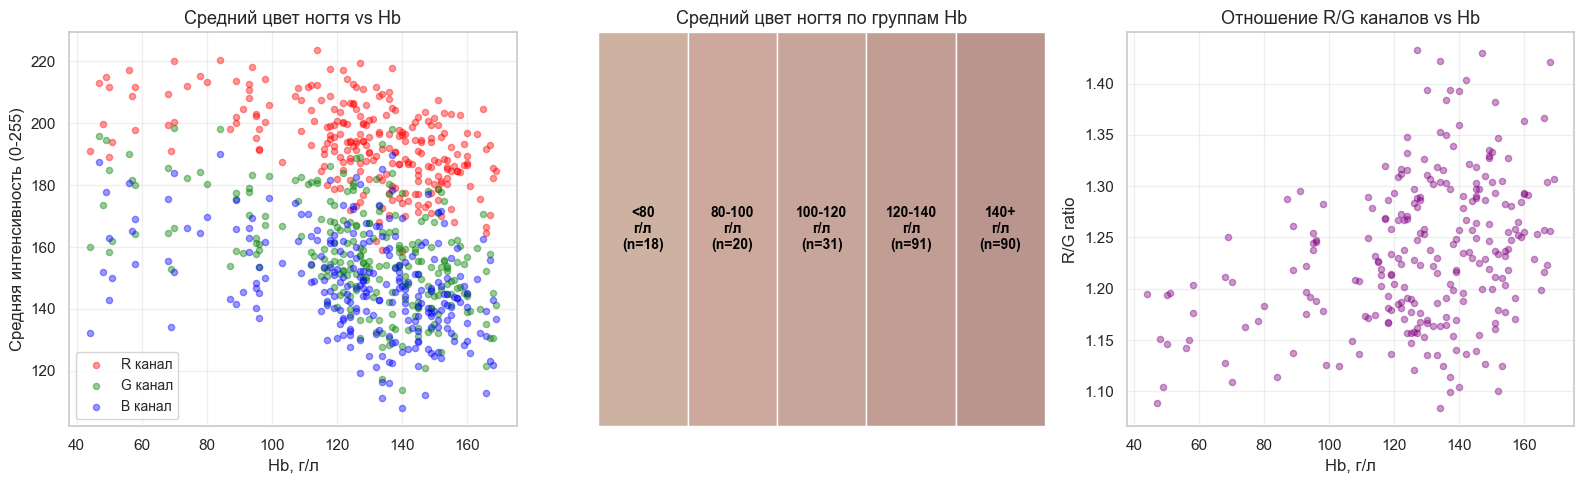

In [ ]:
# Extract all middle finger nail crops
all_nail_crops = []
for _, row in metadata.iterrows():
    img = skio.imread(os.path.join(image_folder, f'{row.PATIENT_ID}.jpg'))
    top, left, bot, right = row.NAIL_BOUNDING_BOXES[1]
    all_nail_crops.append(img[top:bot, left:right])

# Compute mean RGB for each nail
mean_colors = np.array([
    [nail[:,:,ch].mean() for ch in range(3)]
    for nail in all_nail_crops
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Mean R, G, B vs Hb
for ch, (color, name) in enumerate(zip(['red', 'green', 'blue'], ['R', 'G', 'B'])):
    axes[0].scatter(target, mean_colors[:, ch], alpha=0.4, color=color, s=20, label=f'{name} канал')
axes[0].set_xlabel('Hb, г/л', fontsize=12)
axes[0].set_ylabel('Средняя интенсивность (0-255)', fontsize=12)
axes[0].set_title('Средний цвет ногтя vs Hb', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. Color patches for Hb groups
bins = [0, 80, 100, 120, 140, 170]
bin_labels = ['<80', '80-100', '100-120', '120-140', '140+']
for i in range(len(bins) - 1):
    mask = (target >= bins[i]) & (target < bins[i+1])
    if mask.sum() > 0:
        avg_color = mean_colors[mask].mean(axis=0) / 255.0
        rect = mpatches.Rectangle((i, 0), 1, 1, facecolor=avg_color)
        axes[1].add_patch(rect)
        axes[1].text(i + 0.5, 0.5, f'{bin_labels[i]}\nг/л\n(n={mask.sum()})',
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if avg_color.mean() < 0.6 else 'black')
axes[1].set_xlim(0, len(bins) - 1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Средний цвет ногтя по группам Hb', fontsize=13)
axes[1].axis('off')

# 3. R/G ratio vs Hb (often informative)
rg_ratio = mean_colors[:, 0] / (mean_colors[:, 1] + 1e-6)
axes[2].scatter(target, rg_ratio, alpha=0.4, color='purple', s=20)
axes[2].set_xlabel('Hb, г/л', fontsize=12)
axes[2].set_ylabel('R/G ratio', fontsize=12)
axes[2].set_title('Отношение R/G каналов vs Hb', fontsize=13)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Вывод из EDA:**
> - При более высоком Hb ногти в среднем **темнее** (больше поглощение)
> - Зелёный канал (G) наиболее чувствителен к изменению Hb (гемоглобин поглощает зелёный свет)
> - Отношение R/G может служить информативным признаком
> - Различия между группами есть, но они **не очень большие** — задача непростая!

## 4. Извлечение признаков (Feature Engineering)

### Что такое признаки (features)?

**Признаки** — числовые характеристики, которые мы извлекаем из данных и подаём в модель.
Модель машинного обучения не может работать напрямую с изображениями — ей нужны числа.

### Наш подход: перцентили интенсивности

Для каждого канала (R, G, B) вычисляем **перцентили** — значения, ниже которых
находится определённый процент пикселей:

| Перцентиль | Что показывает |
|------------|---------------|
| 5-й | Самые тёмные участки ногтя |
| 25-й | Нижняя четверть яркости |
| 50-й (медиана) | Типичная яркость |
| 75-й | Верхняя четверть яркости |
| 95-й | Самые светлые участки |

> **Почему перцентили, а не просто среднее?** Перцентили дают более полное описание
> распределения яркости — они описывают и тёмные, и светлые области ногтя.

### Нормализация по белому эталону

Чтобы яркость не зависела от условий освещения, делим значения на яркость
**белого фона** на изображении (белая область — стандарт для калибровки).

**Итого: 7 перцентилей × 3 канала × 2 области (ноготь + кожа) = 42 признака**

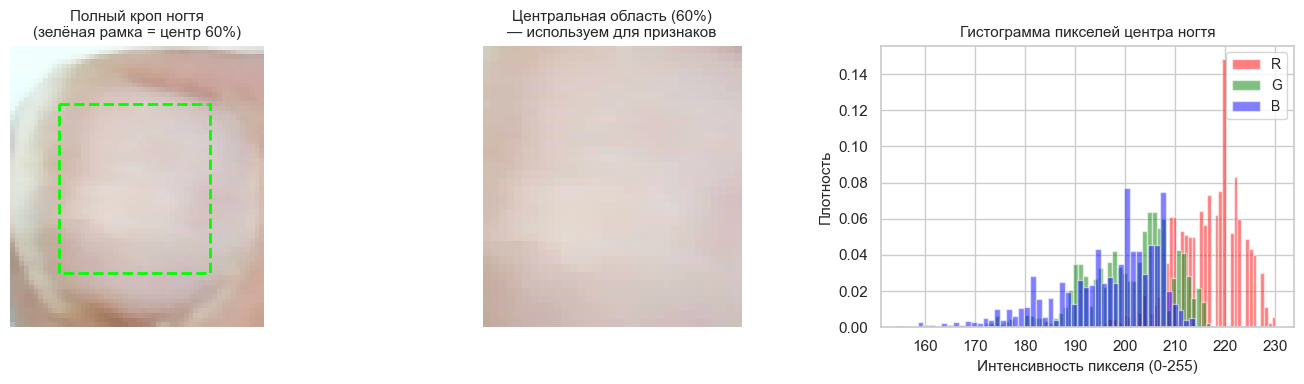

Стрелки показывают перцентили 5%, 50%, 95% для красного канала:
  P5 = 205
  P50 = 218
  P95 = 226


In [ ]:
# Визуализация: что делает cut_image
sample_row = metadata.iloc[0]
sample_img = skio.imread(os.path.join(image_folder, f'{sample_row.PATIENT_ID}.jpg'))
top, left, bot, right = sample_row.NAIL_BOUNDING_BOXES[1]
sample_nail = sample_img[top:bot, left:right]

h, w = sample_nail.shape[:2]
low, high = 0.2, 0.8
center = sample_nail[int(low*h):int(high*h), int(low*w):int(high*w), :]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(sample_nail)
rect = mpatches.Rectangle((int(low*w), int(low*h)),
                           int((high-low)*w), int((high-low)*h),
                           fill=False, color='lime', linewidth=2, linestyle='--')
axes[0].add_patch(rect)
axes[0].set_title('Полный кроп ногтя\n(зелёная рамка = центр 60%)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(center)
axes[1].set_title('Центральная область (60%)\n— используем для признаков', fontsize=11)
axes[1].axis('off')

# Histogram of pixel intensities
for ch, (color, name) in enumerate(zip(['red', 'green', 'blue'], ['R', 'G', 'B'])):
    axes[2].hist(center[:,:,ch].ravel(), bins=50, alpha=0.5, color=color, label=name, density=True)
axes[2].set_xlabel('Интенсивность пикселя (0-255)', fontsize=11)
axes[2].set_ylabel('Плотность', fontsize=11)
axes[2].set_title('Гистограмма пикселей центра ногтя', fontsize=11)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()
print("Стрелки показывают перцентили 5%, 50%, 95% для красного канала:")
r_channel = center[:,:,0].ravel()
for p in [5, 50, 95]:
    print(f"  P{p} = {np.percentile(r_channel, p):.0f}")

In [ ]:
def cut_image(img, low=0.2, high=0.8):
    """Вырезает центральные 60% изображения."""
    h, w = img.shape[:2]
    return img[int(low*h):int(high*h), int(low*w):int(high*w), :]

def calculate_features(img, percentiles=[5, 15, 25, 50, 75, 85, 95]):
    """Вычисляет перцентили интенсивности по R, G, B каналам."""
    features = {}
    cropped = cut_image(img)
    for ch_id, color in enumerate('RGB'):
        for p in percentiles:
            features[f'{color}_p{p}'] = np.percentile(cropped[:,:,ch_id].ravel(), p)
    return features

# Load all images and extract regions
all_images = defaultdict(list)

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc='Loading images'):
    img = skio.imread(os.path.join(image_folder, f'{row.PATIENT_ID}.jpg'))
    for site, bboxes in zip(['NAIL', 'SKIN'], [row.NAIL_BOUNDING_BOXES, row.SKIN_BOUNDING_BOXES]):
        for num, (t, l, b, r) in enumerate(bboxes, start=1):
            all_images[f'{site}_{num}'].append(img[t:b, l:r])
    all_images['WHITE_REF'].append(img[350:400, 300:350])

# Features from middle finger (NAIL_2, SKIN_2)
white_ref = pd.DataFrame({
    c: [np.median(img[:,:,i].ravel()) for img in all_images['WHITE_REF']]
    for i, c in enumerate('RGB')
})
nail_feat = pd.DataFrame([calculate_features(img) for img in all_images['NAIL_2']])
nail_feat = nail_feat.rename(columns=lambda x: f'NAIL_{x}')
skin_feat = pd.DataFrame([calculate_features(img) for img in all_images['SKIN_2']])
skin_feat = skin_feat.rename(columns=lambda x: f'SKIN_{x}')

features = pd.concat([nail_feat, skin_feat], axis=1)

# Normalize by white reference
for col in features.columns:
    color = col.split('_')[1]
    features[col] = features[col] / white_ref[color]

print(f'Матрица признаков: {features.shape[0]} пациентов × {features.shape[1]} признаков')

Loading images: 100%|██████████| 250/250 [00:02<00:00, 99.85it/s] 


Матрица признаков: 250 пациентов × 42 признаков


### Корреляция признаков с уровнем Hb

Посмотрим, какие признаки наиболее связаны с гемоглобином.
Это поможет понять, какие каналы и перцентили наиболее информативны.

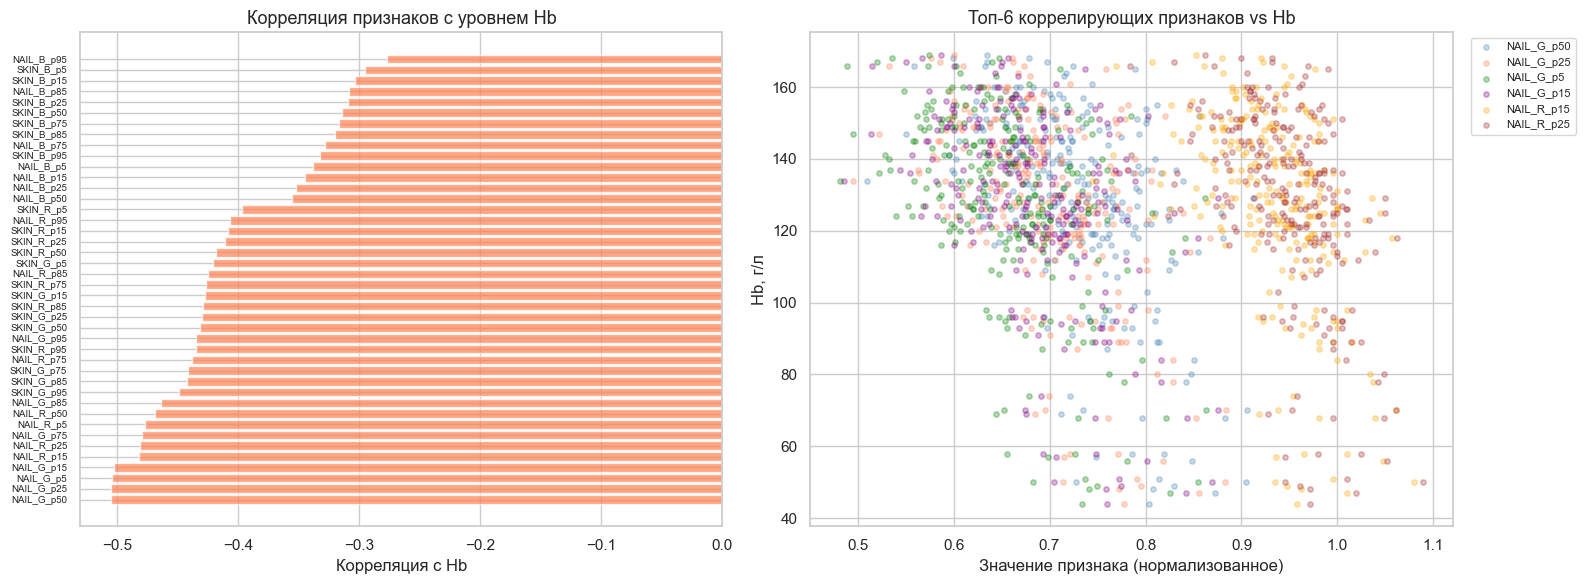

In [ ]:
# Correlation of each feature with target
correlations = features.corrwith(target).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar plot of correlations
colors_bar = ['coral' if c < 0 else 'steelblue' for c in correlations]
axes[0].barh(range(len(correlations)), correlations.values, color=colors_bar, alpha=0.7)
axes[0].set_yticks(range(len(correlations)))
axes[0].set_yticklabels(correlations.index, fontsize=7)
axes[0].set_xlabel('Корреляция с Hb', fontsize=12)
axes[0].set_title('Корреляция признаков с уровнем Hb', fontsize=13)
axes[0].axvline(x=0, color='black', linewidth=0.5)

# 2. Top 6 features scatter
top_features = correlations.abs().nlargest(6).index
for i, feat in enumerate(top_features):
    color_cycle = ['steelblue', 'coral', 'green', 'purple', 'orange', 'brown']
    axes[1].scatter(features[feat], target, alpha=0.3, s=15,
                   color=color_cycle[i % len(color_cycle)], label=feat)
axes[1].set_xlabel('Значение признака (нормализованное)', fontsize=12)
axes[1].set_ylabel('Hb, г/л', fontsize=12)
axes[1].set_title('Топ-6 коррелирующих признаков vs Hb', fontsize=13)
axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Балансировка выборки

### Зачем нужна балансировка?

В нашем датасете **большинство пациентов здоровы** (Hb > 120).
Если обучить модель на таких данных, она будет хорошо предсказывать нормальный Hb,
но плохо — низкий (анемию).

### Как мы балансируем?

Используем **inverse KDE weighting**:
1. Оцениваем плотность распределения Hb с помощью **KDE** (Kernel Density Estimation)
2. Назначаем каждому пациенту вес, **обратный** плотности: редкие значения получают больший вес
3. Выбираем **100 пациентов** с вероятностью, пропорциональной весу

Это делает выборку более **равномерной** по Hb.
Остальные **150 пациентов** используем для тестирования.

In [ ]:
from matplotlib.lines import Line2D

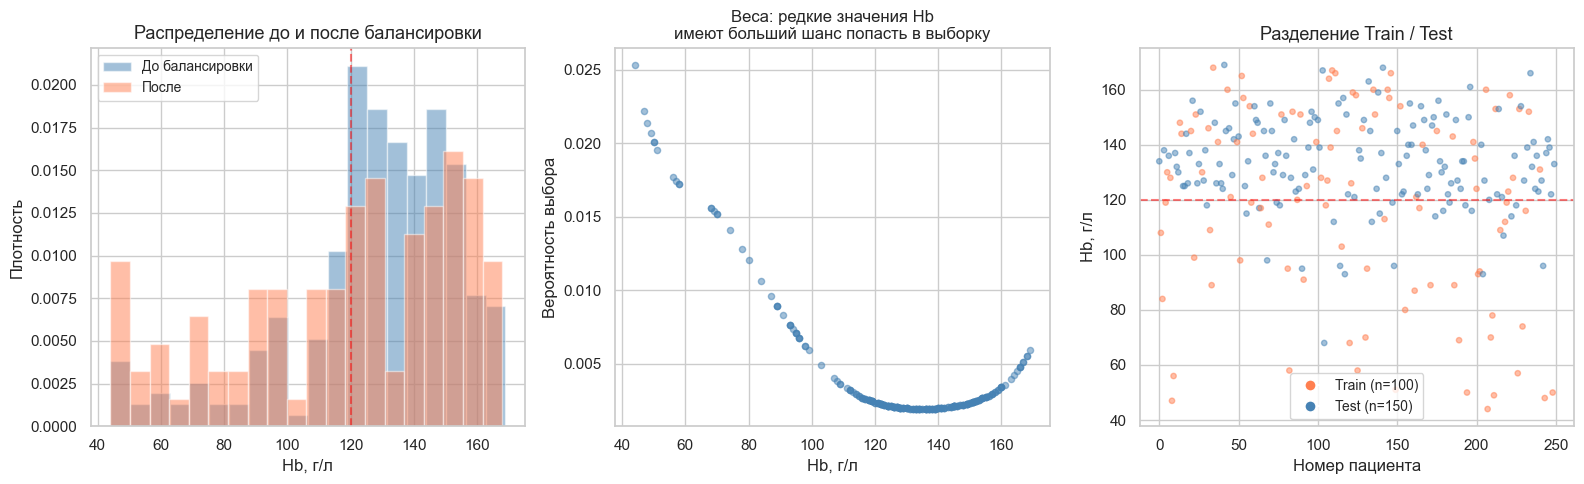

Доля Hb < 120 до балансировки:  27.6%
Доля Hb < 120 после балансировки: 44.0%

Train: 100 пациентов, Test: 150 пациентов


In [ ]:
np.random.seed(42)
target_kde = stats.gaussian_kde(target, bw_method=0.5)(target)
weights = 1 / target_kde
weights /= np.sum(weights)

balanced_ids = np.random.choice(metadata['PATIENT_ID'], size=100, replace=False, p=weights)
balancing_mask = metadata['PATIENT_ID'].isin(balanced_ids).values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Before/after histograms
axes[0].hist(target, density=True, alpha=0.5, label='До балансировки', color='steelblue', bins=20)
axes[0].hist(target[balancing_mask], density=True, alpha=0.5, label='После', color='coral', bins=20)
axes[0].axvline(x=120, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Hb, г/л', fontsize=12)
axes[0].set_ylabel('Плотность', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_title('Распределение до и после балансировки', fontsize=13)

# 2. Sampling weights
axes[1].scatter(target, weights, alpha=0.5, color='steelblue', s=20)
axes[1].set_xlabel('Hb, г/л', fontsize=12)
axes[1].set_ylabel('Вероятность выбора', fontsize=12)
axes[1].set_title('Веса: редкие значения Hb\nимеют больший шанс попасть в выборку', fontsize=12)

# 3. Train/test split visualization
axes[2].scatter(range(len(target)), target, c=['coral' if m else 'steelblue' for m in balancing_mask],
               alpha=0.5, s=15)
axes[2].axhline(y=120, color='red', linestyle='--', alpha=0.5)
legend_el = [Line2D([0], [0], marker='o', color='w', markerfacecolor='coral', label=f'Train (n={balancing_mask.sum()})', markersize=8),
             Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', label=f'Test (n={(~balancing_mask).sum()})', markersize=8)]
axes[2].legend(handles=legend_el, fontsize=10)
axes[2].set_xlabel('Номер пациента', fontsize=12)
axes[2].set_ylabel('Hb, г/л', fontsize=12)
axes[2].set_title('Разделение Train / Test', fontsize=13)

plt.tight_layout()
plt.show()

print(f'Доля Hb < 120 до балансировки:  {np.mean(target < 120):.1%}')
print(f'Доля Hb < 120 после балансировки: {np.mean(target[balancing_mask] < 120):.1%}')
print(f'\nTrain: {balancing_mask.sum()} пациентов, Test: {(~balancing_mask).sum()} пациентов')

## 5. Baseline: Классический Machine Learning

### Что такое baseline?

**Baseline** — простая модель, с которой мы сравниваем более сложные подходы.
Если DL не лучше baseline — значит, он не оправдывает свою сложность.

### ElasticNet: Регуляризованная линейная регрессия

**Линейная регрессия** предполагает, что целевая переменная (Hb) — линейная комбинация признаков:

$$Hb = w_1 \cdot feature_1 + w_2 \cdot feature_2 + ... + w_{42} \cdot feature_{42} + b$$

**Проблема:** при 42 признаках и 100 пациентах модель может **переобучиться** (overfitting) —
идеально выучить обучающие данные, но плохо работать на новых.

**ElasticNet** борется с переобучением с помощью **регуляризации**:
- **L1 (Lasso)**: обнуляет веса неважных признаков → отбор признаков
- **L2 (Ridge)**: уменьшает все веса → более гладкая модель
- **ElasticNet = L1 + L2**: комбинация обоих подходов

### Cross-Validation (Кросс-валидация)

Как оценить модель, если данных мало? Используем **K-fold Cross-Validation**:
1. Делим данные на K частей (у нас K=7)
2. Обучаем на K-1 частях, проверяем на оставшейся
3. Повторяем K раз, каждый раз оставляя другую часть
4. Усредняем результат → **надёжная оценка** качества модели

In [ ]:
X_train_ml = features[balancing_mask]
y_train_ml = target[balancing_mask].values
X_test_ml = features[~balancing_mask]
y_test_ml = target[~balancing_mask].values

print(f'Обучающая выборка: {X_train_ml.shape[0]} пациентов, {X_train_ml.shape[1]} признаков')
print(f'Тестовая выборка:  {X_test_ml.shape[0]} пациентов')

# Pipeline: масштабирование + регрессия
pipeline = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.RobustScaler()),   # масштабирование признаков
    ('regressor', sklearn.linear_model.ElasticNet(max_iter=10000))  # регрессия
])

# Подбор гиперпараметров с помощью GridSearchCV
grid_search = sklearn.model_selection.GridSearchCV(
    pipeline,
    param_grid={
        'regressor__l1_ratio': [0.01, 0.1, 0.5, 0.9, 0.99],  # баланс L1/L2
        'regressor__alpha': np.logspace(-4, 4, num=50)         # сила регуляризации
    },
    cv=sklearn.model_selection.KFold(n_splits=7),
    scoring=sklearn.metrics.make_scorer(
        sklearn.metrics.root_mean_squared_error, greater_is_better=False
    ),
    verbose=0
)

grid_search.fit(X_train_ml, y_train_ml)
print(f'\nЛучший CV RMSE: {-grid_search.best_score_:.1f} г/л')
print(f'Лучшие параметры: {grid_search.best_params_}')

Обучающая выборка: 100 пациентов, 42 признаков
Тестовая выборка:  150 пациентов

Лучший CV RMSE: 23.9 г/л
Лучшие параметры: {'regressor__alpha': np.float64(0.18420699693267145), 'regressor__l1_ratio': 0.9}


### Оценка baseline модели

Метрика **RMSE (Root Mean Squared Error)** — средняя ошибка в г/л.
Чем меньше RMSE, тем лучше.

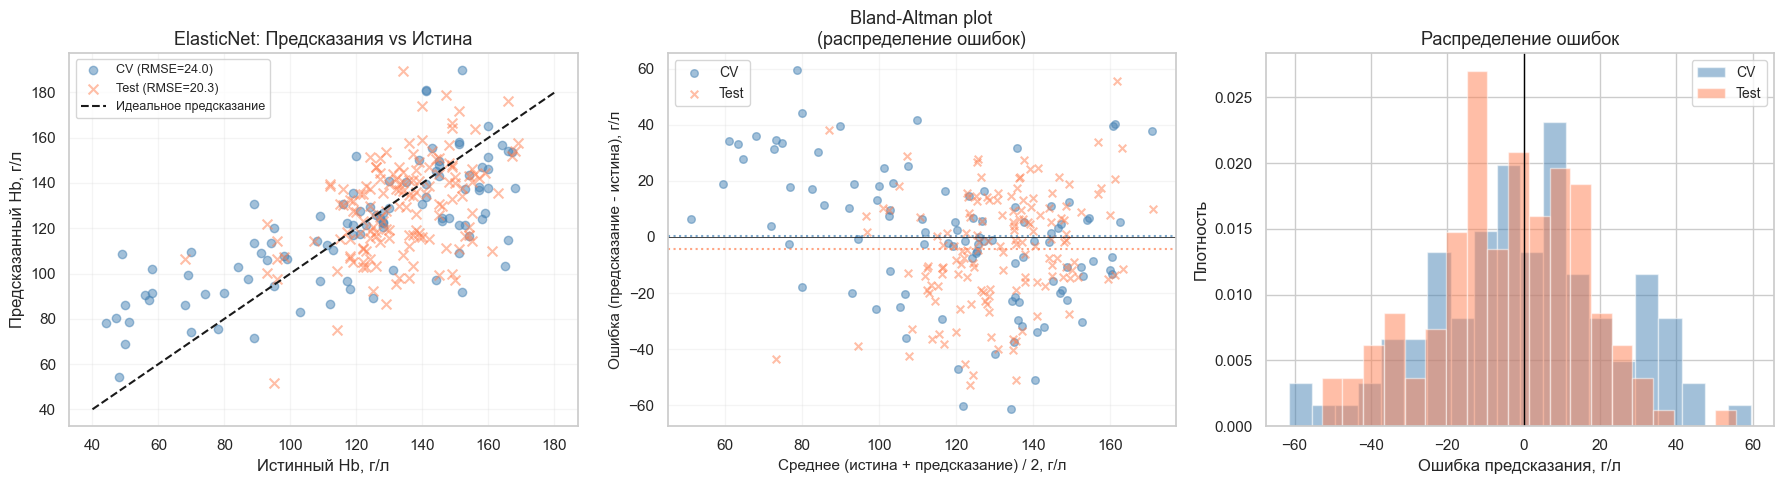


ElasticNet — Validation RMSE: 24.0 г/л
ElasticNet — Test RMSE: 20.3 г/л

Для контекста: ошибка 20 г/л означает, что модель
в среднем ошибается на 20 г/л при предсказании уровня Hb.


In [ ]:
best_ml = pipeline.set_params(**grid_search.best_params_)

cv = sklearn.model_selection.KFold(n_splits=7)
y_pred_cv = sklearn.model_selection.cross_val_predict(best_ml, X_train_ml, y=y_train_ml, cv=cv)

best_ml.fit(X_train_ml, y_train_ml)
y_pred_test_ml = best_ml.predict(X_test_ml)

rmse_val_ml = sklearn.metrics.root_mean_squared_error(y_train_ml, y_pred_cv)
rmse_test_ml = sklearn.metrics.root_mean_squared_error(y_test_ml, y_pred_test_ml)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter: predicted vs true
axes[0].scatter(y_train_ml, y_pred_cv, alpha=0.5, label=f'CV (RMSE={rmse_val_ml:.1f})', color='steelblue')
axes[0].scatter(y_test_ml, y_pred_test_ml, alpha=0.5, label=f'Test (RMSE={rmse_test_ml:.1f})', color='coral', marker='x', s=50)
axes[0].plot([40, 180], [40, 180], 'k--', label='Идеальное предсказание')
axes[0].set_xlabel('Истинный Hb, г/л', fontsize=12)
axes[0].set_ylabel('Предсказанный Hb, г/л', fontsize=12)
axes[0].set_title('ElasticNet: Предсказания vs Истина', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# 2. Bland-Altman plot
for y_true, y_pred, color, label, marker in [
    (y_train_ml, y_pred_cv, 'steelblue', 'CV', 'o'),
    (y_test_ml, y_pred_test_ml, 'coral', 'Test', 'x')
]:
    avg = (y_true + y_pred) / 2
    diff = y_pred - y_true
    axes[1].scatter(avg, diff, alpha=0.5, color=color, label=label, marker=marker, s=30)
    bias = np.mean(diff)
    sd = np.std(diff)
    axes[1].axhline(bias, color=color, linestyle=':', alpha=0.7)

axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Среднее (истина + предсказание) / 2, г/л', fontsize=11)
axes[1].set_ylabel('Ошибка (предсказание - истина), г/л', fontsize=11)
axes[1].set_title('Bland-Altman plot\n(распределение ошибок)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.2)

# 3. Error histogram
errors_cv = y_pred_cv - y_train_ml
errors_test = y_pred_test_ml - y_test_ml
axes[2].hist(errors_cv, bins=20, alpha=0.5, color='steelblue', label='CV', density=True)
axes[2].hist(errors_test, bins=20, alpha=0.5, color='coral', label='Test', density=True)
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_xlabel('Ошибка предсказания, г/л', fontsize=12)
axes[2].set_ylabel('Плотность', fontsize=12)
axes[2].set_title('Распределение ошибок', fontsize=13)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nElasticNet — Validation RMSE: {rmse_val_ml:.1f} г/л')
print(f'ElasticNet — Test RMSE: {rmse_test_ml:.1f} г/л')
print(f'\nДля контекста: ошибка {rmse_test_ml:.0f} г/л означает, что модель')
print(f'в среднем ошибается на {rmse_test_ml:.0f} г/л при предсказании уровня Hb.')

### Важность признаков

Какие признаки модель считает наиболее важными?
У ElasticNet можно посмотреть **веса (коэффициенты)** — чем больше |вес|, тем важнее признак.

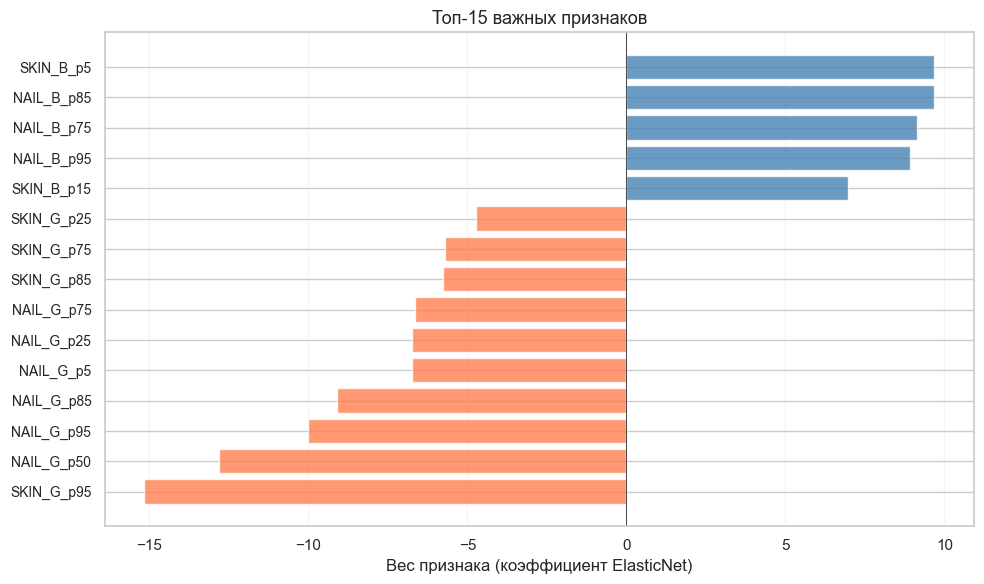

Признаков с нулевым весом (отброшены L1): 13 из 42
Признаков используется: 29


In [ ]:
# Get feature importances (ElasticNet coefficients)
coefs = best_ml.named_steps['regressor'].coef_
feat_importance = pd.Series(coefs, index=features.columns).sort_values()

# Show top 10 most important (by absolute value)
top_n = 15
top_feat = feat_importance.abs().nlargest(top_n).index
top_vals = feat_importance[top_feat].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['coral' if v < 0 else 'steelblue' for v in top_vals]
ax.barh(range(len(top_vals)), top_vals.values, color=colors_imp, alpha=0.8)
ax.set_yticks(range(len(top_vals)))
ax.set_yticklabels(top_vals.index, fontsize=10)
ax.set_xlabel('Вес признака (коэффициент ElasticNet)', fontsize=12)
ax.set_title(f'Топ-{top_n} важных признаков', fontsize=13)
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

n_zero = (np.abs(coefs) < 1e-10).sum()
print(f'Признаков с нулевым весом (отброшены L1): {n_zero} из {len(coefs)}')
print(f'Признаков используется: {len(coefs) - n_zero}')

## 6. Deep Learning: Transfer Learning с ResNet18

Теперь попробуем подход Deep Learning — вместо ручного извлечения признаков
(перцентили) **обучим нейросеть** самостоятельно находить полезные паттерны в изображениях.

### Свёрточные нейросети (CNN)

**CNN (Convolutional Neural Network)** — тип нейросети, специально разработанный для изображений.

Как работает CNN (упрощённо):
1. **Свёрточные слои** — скользят маленькими фильтрами по изображению, выделяя паттерны
   - Первые слои: простые паттерны (края, линии, цвета)
   - Средние слои: более сложные паттерны (текстуры, формы)
   - Глубокие слои: высокоуровневые паттерны (объекты, их части)
2. **Pooling слои** — уменьшают размер, сохраняя важную информацию
3. **Полносвязные слои** — принимают решение на основе извлечённых признаков

### Transfer Learning (перенос обучения)

Обучение CNN с нуля требует **миллионов** изображений. У нас всего 250.

**Решение — Transfer Learning:**
1. Берём CNN, уже обученную на **ImageNet** (1.2 млн изображений, 1000 классов)
2. Её ранние слои уже умеют извлекать полезные признаки (края, текстуры, цвета)
3. **Замораживаем** ранние слои (не обучаем их)
4. **Дообучаем** только последние слои на нашей задаче

### ResNet18

**ResNet** (Residual Network) — одна из самых популярных архитектур CNN.
Ключевая идея — **skip connections** (остаточные связи), которые помогают
обучать глубокие сети.

**ResNet18** — лёгкая версия с 18 слоями. Идеально подходит для малых датасетов.

Наш план:
- Замораживаем все свёрточные слои (CNN = фиксированный экстрактор признаков)
- Заменяем классификатор (1000 классов) на регрессионную голову (512 → 64 → 1)
- Обучаем только новую «голову» на кропах ногтей

### Шаг 1: Подготовка изображений ногтей

Для нейросети нам нужны не числовые признаки, а **сами изображения** ногтей.
Вырежем кропы среднего пальца для всех пациентов.

Extracting nail crops: 100%|██████████| 250/250 [00:02<00:00, 99.09it/s] 


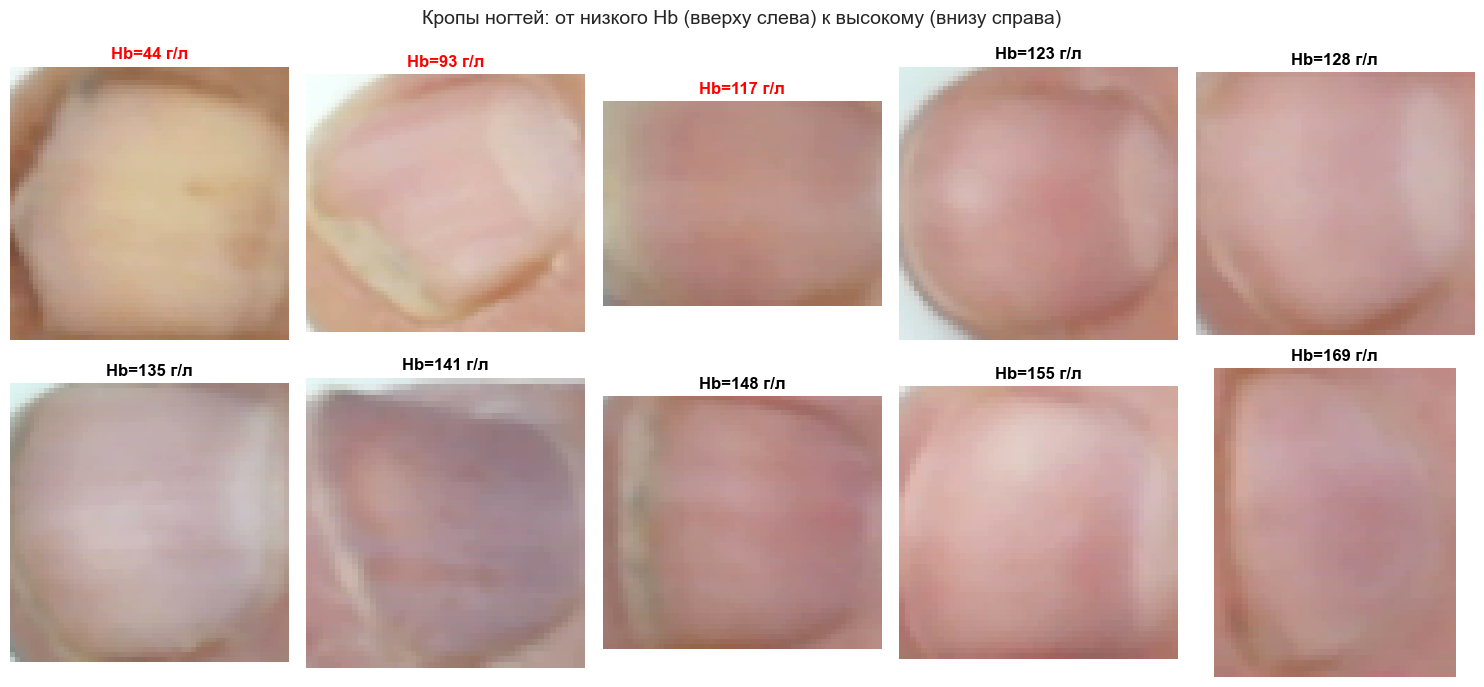


Размеры кропов (пример): (60, 54, 3)
Все кропы будут изменены до 224×224 пикселей для ResNet18


In [ ]:
nail_crops = []
for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc='Extracting nail crops'):
    img = skio.imread(os.path.join(image_folder, f'{row.PATIENT_ID}.jpg'))
    top, left, bot, right = row.NAIL_BOUNDING_BOXES[1]  # средний палец
    nail_crops.append(img[top:bot, left:right])

# Show examples sorted by Hb level
sorted_idx = np.argsort(target.values)
sample_idx = sorted_idx[np.linspace(0, len(sorted_idx)-1, 10, dtype=int)]

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(nail_crops[idx])
    hb = target.iloc[idx]
    color = 'red' if hb < 120 else 'black'
    ax.set_title(f'Hb={hb:.0f} г/л', fontsize=12, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Кропы ногтей: от низкого Hb (вверху слева) к высокому (внизу справа)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nРазмеры кропов (пример): {nail_crops[0].shape}')
print(f'Все кропы будут изменены до 224×224 пикселей для ResNet18')

### Шаг 2: Data Augmentation (аугментация данных)

При малом количестве данных **аугментация** — ключевая техника.
Мы создаём «новые» примеры, применяя случайные трансформации к изображениям:
- Отражение по горизонтали/вертикали
- Поворот на случайный угол
- Изменение яркости, контраста, насыщенности

> **Важно:** аугментация применяется **только при обучении**, не при тестировании!

Посмотрим, как выглядят аугментированные варианты одного ногтя:

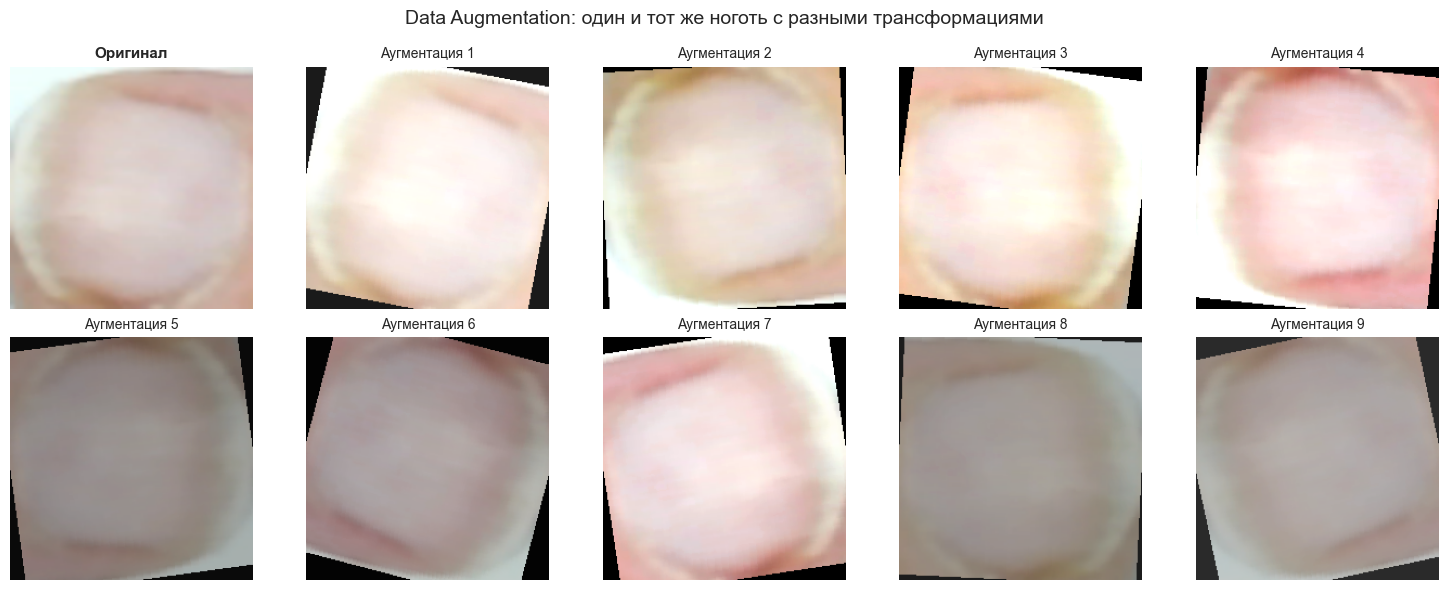

In [ ]:
# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Visualize augmentations (before normalization, for visibility)
aug_visual = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
])

sample_pil = Image.fromarray(nail_crops[0])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_pil.resize((224, 224)))
axes[0, 0].set_title('Оригинал', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.ravel()[1:]):
    augmented = aug_visual(sample_pil)
    ax.imshow(augmented)
    ax.set_title(f'Аугментация {i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('Data Augmentation: один и тот же ноготь с разными трансформациями', fontsize=14)
plt.tight_layout()
plt.show()

### Шаг 3: PyTorch Dataset

PyTorch требует данные в специальном формате — **Dataset**.
Это класс, который умеет:
- Возвращать количество элементов (`__len__`)
- Возвращать один элемент по индексу (`__getitem__`)

In [ ]:
class NailDataset(Dataset):
    """PyTorch Dataset для изображений ногтей."""

    def __init__(self, images, targets, transform=None):
        self.images = images      # список numpy-массивов (кропы ногтей)
        self.targets = targets    # numpy-массив уровней Hb
        self.transform = transform  # трансформации (аугментация + нормализация)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])  # numpy -> PIL Image
        target = torch.tensor(self.targets[idx], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)  # применяем трансформации
        return image, target  # возвращаем пару (изображение, целевое значение)

print('Dataset class defined.')

Dataset class defined.


### Шаг 4: Создание модели

Создаём ResNet18 с модифицированной «головой» для регрессии:

In [ ]:
def create_model():
    """ResNet18 для регрессии уровня Hb."""
    # Загружаем предобученную на ImageNet модель
    model = models.resnet18(weights='IMAGENET1K_V1')

    # ЗАМОРАЖИВАЕМ ВСЕ свёрточные слои — у нас только 80 изображений,
    # поэтому безопаснее использовать CNN как фиксированный экстрактор признаков
    for param in model.parameters():
        param.requires_grad = False

    # ЗАМЕНЯЕМ классификатор на регрессионную голову
    # Было: Linear(512 -> 1000)  — классификация на 1000 классов ImageNet
    # Стало: Linear(512 -> 64) -> ReLU -> Dropout -> Linear(64 -> 1)
    in_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Linear(in_features, 64),   # 512 -> 64
        nn.ReLU(),
        nn.Dropout(0.3),              # Dropout для борьбы с переобучением
        nn.Linear(64, 1)              # 64 -> 1 (уровень Hb)
    )
    return model.to(device)

model_dl = create_model()

trainable = sum(p.numel() for p in model_dl.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_dl.parameters())
print(f'Обучаемых параметров: {trainable:,} из {total:,} ({trainable/total:.1%})')
print(f'\nЗамороженных: {total - trainable:,} — эти слои УЖЕ обучены на ImageNet')
print(f'Обучаемых:     {trainable:,} — эти слои мы дообучим на ногтях')

Обучаемых параметров: 32,897 из 11,209,409 (0.3%)

Замороженных: 11,176,512 — эти слои УЖЕ обучены на ImageNet
Обучаемых:     32,897 — эти слои мы дообучим на ногтях


### Шаг 5: Подготовка данных (DataLoader)

**DataLoader** — загрузчик данных, который:
- Объединяет изображения в **батчи** (пакеты) — модель обрабатывает сразу несколько изображений
- **Перемешивает** данные каждую эпоху (для обучения)
- Подаёт данные в модель эффективно

Используем тот же split, что и для ML: 100 сбалансированных → train, 150 → test.
Из 100 train выделяем 20% на валидацию.

In [ ]:
from sklearn.model_selection import train_test_split

train_crops = [nail_crops[i] for i in range(len(nail_crops)) if balancing_mask[i]]
test_crops = [nail_crops[i] for i in range(len(nail_crops)) if not balancing_mask[i]]
train_hb = target[balancing_mask].values
test_hb = target[~balancing_mask].values

# Split train -> train/val (80/20)
idx = list(range(len(train_crops)))
tr_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)

train_dataset = NailDataset([train_crops[i] for i in tr_idx], train_hb[tr_idx], train_transform)
val_dataset = NailDataset([train_crops[i] for i in val_idx], train_hb[val_idx], val_transform)
test_dataset = NailDataset(test_crops, test_hb, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f'Train: {len(train_dataset)} изображений ({len(train_loader)} батчей)')
print(f'Val:   {len(val_dataset)} изображений ({len(val_loader)} батчей)')
print(f'Test:  {len(test_dataset)} изображений ({len(test_loader)} батчей)')

Train: 80 изображений (5 батчей)
Val:   20 изображений (2 батчей)
Test:  150 изображений (10 батчей)


### Шаг 6: Обучение модели

**Цикл обучения (training loop)** — сердце Deep Learning:

```
Для каждой эпохи (epoch):
    1. TRAIN: для каждого батча изображений:
       - Прогоняем через модель (forward pass)
       - Считаем ошибку (loss = MSE)
       - Считаем градиенты (backward pass)
       - Обновляем веса (optimizer.step)
    2. VALIDATE: проверяем на валидационной выборке (без обучения)
    3. Сохраняем лучшую модель (по val RMSE)
```

**Гиперпараметры:**
- Эпох: 100 (полных проходов по данным)
- Learning rate: 0.001 (скорость обучения)
- Optimizer: Adam (адаптивный оптимизатор)
- Loss: MSE (Mean Squared Error)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-4):
    """Обучение модели с сохранением лучшего состояния."""
    criterion = nn.MSELoss()  # функция потерь
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),  # только обучаемые параметры
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)

    history = {'train_loss': [], 'val_rmse': []}
    best_val = float('inf')
    best_state = None

    for epoch in range(epochs):
        # === TRAIN ===
        model.train()
        losses = []
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            optimizer.zero_grad()           # обнуляем градиенты
            preds = model(images).view(-1)  # forward pass
            loss = criterion(preds, targets) # считаем ошибку
            loss.backward()                 # backward pass (градиенты)
            optimizer.step()                # обновляем веса
            losses.append(loss.item())

        # === VALIDATE ===
        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():  # без подсчёта градиентов
            for images, targets in val_loader:
                preds = model(images.to(device)).view(-1)
                all_preds.extend(preds.cpu().numpy())
                all_true.extend(targets.numpy())

        val_rmse = np.sqrt(np.mean((np.array(all_preds) - np.array(all_true))**2))
        train_loss = np.mean(losses)
        scheduler.step(val_rmse)

        history['train_loss'].append(train_loss)
        history['val_rmse'].append(val_rmse)

        # Save best model
        if val_rmse < best_val:
            best_val = val_rmse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.0f} | Val RMSE: {val_rmse:.1f} г/л')

    model.load_state_dict(best_state)
    print(f'\nОбучение завершено! Best Val RMSE: {best_val:.1f} г/л')
    return history

print('Начинаем обучение...')
history = train_model(model_dl, train_loader, val_loader, epochs=100, lr=1e-3)

Начинаем обучение...
Epoch 10/100 | Train Loss: 4516 | Val RMSE: 77.1 г/л
Epoch 20/100 | Train Loss: 1965 | Val RMSE: 38.4 г/л
Epoch 30/100 | Train Loss: 1568 | Val RMSE: 39.6 г/л
Epoch 40/100 | Train Loss: 1602 | Val RMSE: 39.1 г/л
Epoch 50/100 | Train Loss: 1705 | Val RMSE: 39.8 г/л
Epoch 60/100 | Train Loss: 1779 | Val RMSE: 39.5 г/л
Epoch 70/100 | Train Loss: 1937 | Val RMSE: 40.0 г/л
Epoch 80/100 | Train Loss: 1720 | Val RMSE: 40.2 г/л
Epoch 90/100 | Train Loss: 1744 | Val RMSE: 40.2 г/л
Epoch 100/100 | Train Loss: 1716 | Val RMSE: 38.7 г/л

Обучение завершено! Best Val RMSE: 37.6 г/л


### Кривые обучения

Графики показывают, как менялись потери (loss) и ошибка (RMSE) в процессе обучения.

**На что обращать внимание:**
- Train loss должен уменьшаться — модель учится
- Val RMSE должен тоже уменьшаться — модель обобщает
- Если Val RMSE растёт, а Train loss падает — **переобучение**

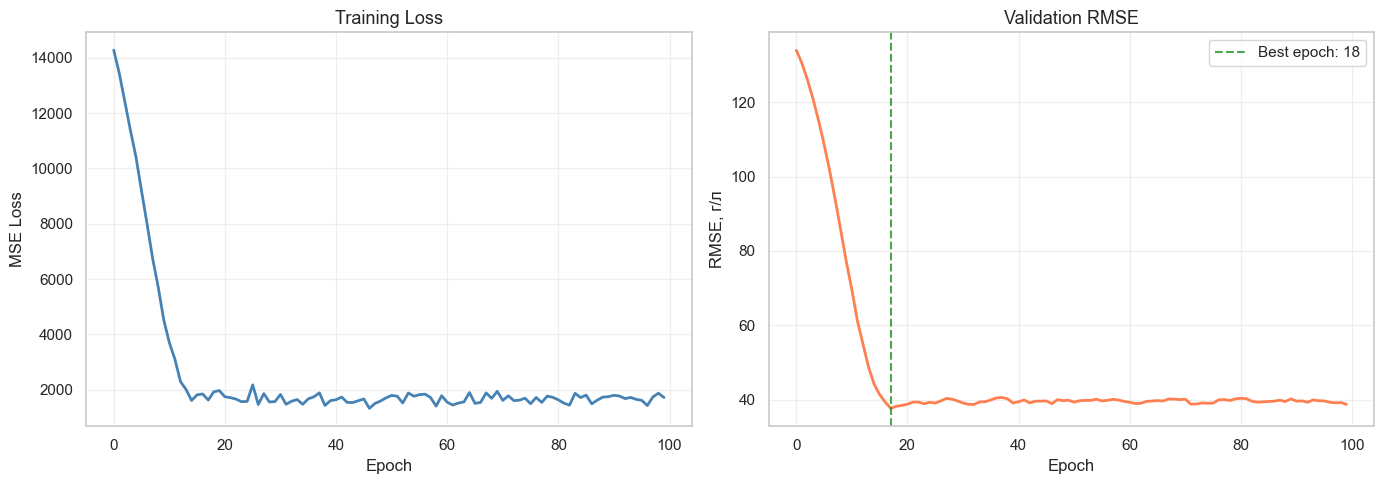

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], color='steelblue', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_rmse'], color='coral', linewidth=2)
best_epoch = np.argmin(history['val_rmse'])
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch+1}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('RMSE, г/л', fontsize=12)
axes[1].set_title('Validation RMSE', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Оценка Deep Learning модели на тесте

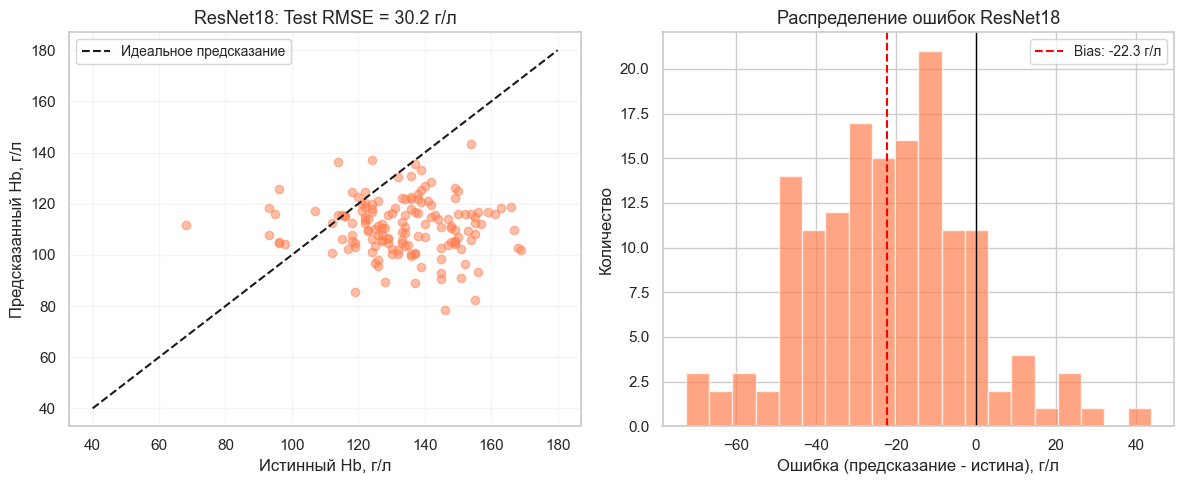

ResNet18 — Test RMSE: 30.2 г/л


In [ ]:
def predict(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for images, targets in loader:
            out = model(images.to(device)).view(-1)
            preds.extend(out.cpu().numpy())
            actuals.extend(targets.numpy())
    return np.array(preds), np.array(actuals)

y_pred_test_dl, y_true_test = predict(model_dl, test_loader)
rmse_test_dl = np.sqrt(np.mean((y_pred_test_dl - y_true_test)**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_true_test, y_pred_test_dl, alpha=0.5, color='coral')
axes[0].plot([40, 180], [40, 180], 'k--', label='Идеальное предсказание')
axes[0].set_xlabel('Истинный Hb, г/л', fontsize=12)
axes[0].set_ylabel('Предсказанный Hb, г/л', fontsize=12)
axes[0].set_title(f'ResNet18: Test RMSE = {rmse_test_dl:.1f} г/л', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.2)

# Error histogram
errors_dl = y_pred_test_dl - y_true_test
axes[1].hist(errors_dl, bins=20, alpha=0.7, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].axvline(np.mean(errors_dl), color='red', linestyle='--',
                label=f'Bias: {np.mean(errors_dl):.1f} г/л')
axes[1].set_xlabel('Ошибка (предсказание - истина), г/л', fontsize=12)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].set_title('Распределение ошибок ResNet18', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()
print(f'ResNet18 — Test RMSE: {rmse_test_dl:.1f} г/л')

## 6b. Full Fine-Tuning: ResNet18 с полной разморозкой

В предыдущем подходе мы **замораживали** все свёрточные слои ResNet18 и обучали только «голову».
Это безопасно при малом объёме данных, но ограничивает способность модели адаптироваться.

### Что меняем?

| | Шаг 6 (Transfer Learning) | Шаг 6b (Full Fine-Tuning) |
|---|---|---|
| **Свёрточные слои** | Заморожены | Все обучаемые |
| **Голова** | Linear → ReLU → Dropout → Linear | Linear → **BatchNorm** → ReLU → Dropout → Linear |
| **Выборка (train)** | 80 сбалансированных | ~175 (стратифицированный сплит) |
| **Выборка (test)** | 150 оставшихся | ~40 (стратифицированный сплит) |

### Зачем BatchNorm в голове?

**Batch Normalization** нормализует активации между слоями:
- Стабилизирует обучение при разморозке всех слоёв
- Позволяет использовать более высокий learning rate
- Работает как лёгкая регуляризация

### Стратифицированный сплит

Вместо случайной балансировки KDE мы **делим весь датасет** на train/val/test,
сохраняя **одинаковое распределение Hb** в каждой части.
Это даёт больше данных для обучения.

In [ ]:
def create_model_finetune():
    """ResNet18 с полной разморозкой и BatchNorm в голове."""
    model = models.resnet18(weights='IMAGENET1K_V1')

    # НЕ замораживаем — все слои будут дообучаться
    # (по умолчанию requires_grad=True для всех параметров)

    in_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Linear(in_features, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 1)
    )
    return model.to(device)

model_ft = create_model_finetune()

trainable_ft = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total_ft = sum(p.numel() for p in model_ft.parameters())
print(f'Обучаемых параметров: {trainable_ft:,} из {total_ft:,} ({trainable_ft/total_ft:.1%})')
print(f'(Для сравнения: в замороженной версии было {trainable:,})')

Обучаемых параметров: 11,209,537 из 11,209,537 (100.0%)
(Для сравнения: в замороженной версии было 32,897)


### Стратифицированный train/val/test split

Разобьём **весь датасет** (не только сбалансированную подвыборку) на 70/15/15,
стратифицируя по квантилям уровня Hb — чтобы в каждой части были и анемичные, и здоровые пациенты.

In [ ]:
# Бинируем Hb на 5 квантилей для стратификации
hb_bins = pd.qcut(target, q=5, labels=False)

all_idx = np.arange(len(nail_crops))

# 70% train, 30% temp
train_idx_ft, temp_idx_ft = train_test_split(
    all_idx, test_size=0.3, random_state=42, stratify=hb_bins
)
# 50/50 val/test из temp -> 15%/15% от всего
val_idx_ft, test_idx_ft = train_test_split(
    temp_idx_ft, test_size=0.5, random_state=42, stratify=hb_bins[temp_idx_ft]
)

train_crops_ft = [nail_crops[i] for i in train_idx_ft]
val_crops_ft = [nail_crops[i] for i in val_idx_ft]
test_crops_ft = [nail_crops[i] for i in test_idx_ft]

train_hb_ft = target.values[train_idx_ft]
val_hb_ft = target.values[val_idx_ft]
test_hb_ft = target.values[test_idx_ft]

train_dataset_ft = NailDataset(train_crops_ft, train_hb_ft, train_transform)
val_dataset_ft = NailDataset(val_crops_ft, val_hb_ft, val_transform)
test_dataset_ft = NailDataset(test_crops_ft, test_hb_ft, val_transform)

train_loader_ft = DataLoader(train_dataset_ft, batch_size=16, shuffle=True)
val_loader_ft = DataLoader(val_dataset_ft, batch_size=16, shuffle=False)
test_loader_ft = DataLoader(test_dataset_ft, batch_size=16, shuffle=False)

print(f'Train: {len(train_dataset_ft)} изображений')
print(f'Val:   {len(val_dataset_ft)} изображений')
print(f'Test:  {len(test_dataset_ft)} изображений')

# Проверим стратификацию
for name, idx in [('Train', train_idx_ft), ('Val', val_idx_ft), ('Test', test_idx_ft)]:
    hb = target.values[idx]
    anemia_pct = (hb < 120).mean() * 100
    print(f'{name}: среднее Hb = {hb.mean():.1f}, доля анемии = {anemia_pct:.0f}%')

Train: 175 изображений
Val:   37 изображений
Test:  38 изображений
Train: среднее Hb = 127.7, доля анемии = 29%
Val: среднее Hb = 129.0, доля анемии = 24%
Test: среднее Hb = 125.6, доля анемии = 26%


### Обучение с полной разморозкой

Используем **меньший learning rate** (1e-4) — при обновлении предобученных свёрточных весов
важно не «сломать» уже выученные признаки.

In [ ]:
print('Начинаем обучение (full fine-tuning)...')
history_ft = train_model(model_ft, train_loader_ft, val_loader_ft, epochs=100, lr=3e-2)

Начинаем обучение (full fine-tuning)...
Epoch 10/100 | Train Loss: 925 | Val RMSE: 187.6 г/л
Epoch 20/100 | Train Loss: 859 | Val RMSE: 24.8 г/л
Epoch 30/100 | Train Loss: 939 | Val RMSE: 24.6 г/л
Epoch 40/100 | Train Loss: 766 | Val RMSE: 26.7 г/л
Epoch 50/100 | Train Loss: 978 | Val RMSE: 25.6 г/л
Epoch 60/100 | Train Loss: 881 | Val RMSE: 26.1 г/л
Epoch 70/100 | Train Loss: 832 | Val RMSE: 26.0 г/л
Epoch 80/100 | Train Loss: 856 | Val RMSE: 26.1 г/л
Epoch 90/100 | Train Loss: 859 | Val RMSE: 25.8 г/л
Epoch 100/100 | Train Loss: 803 | Val RMSE: 26.0 г/л

Обучение завершено! Best Val RMSE: 24.4 г/л


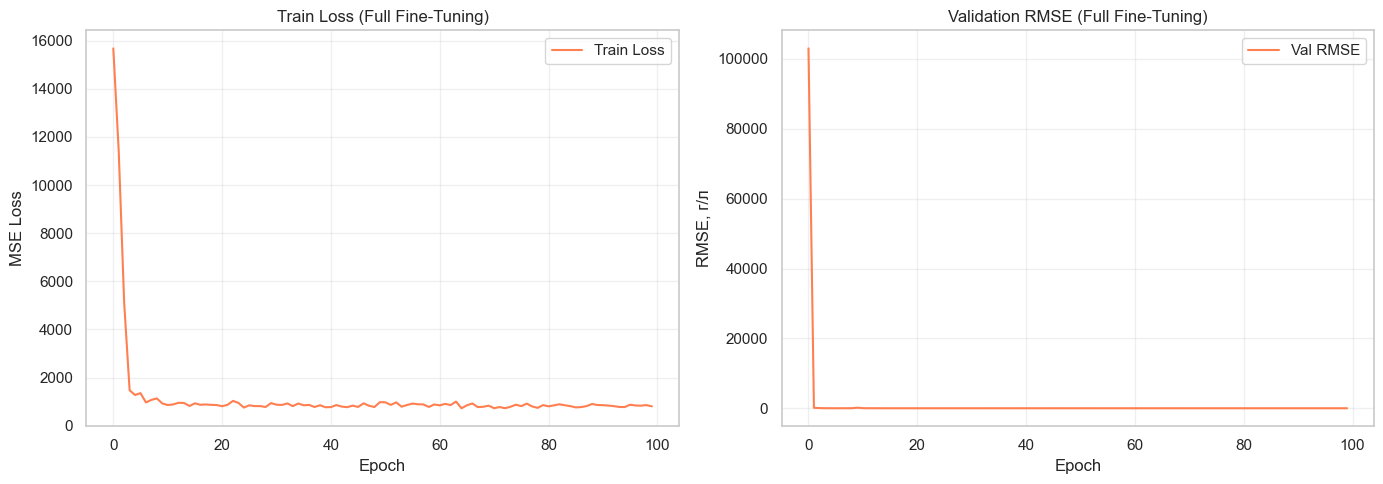

Best Val RMSE: 24.4 г/л


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ft['train_loss'], label='Train Loss', color='coral')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Train Loss (Full Fine-Tuning)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_ft['val_rmse'], label='Val RMSE', color='coral')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE, г/л')
axes[1].set_title('Validation RMSE (Full Fine-Tuning)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Best Val RMSE: {min(history_ft["val_rmse"]):.1f} г/л')

### Оценка Full Fine-Tuning на тесте

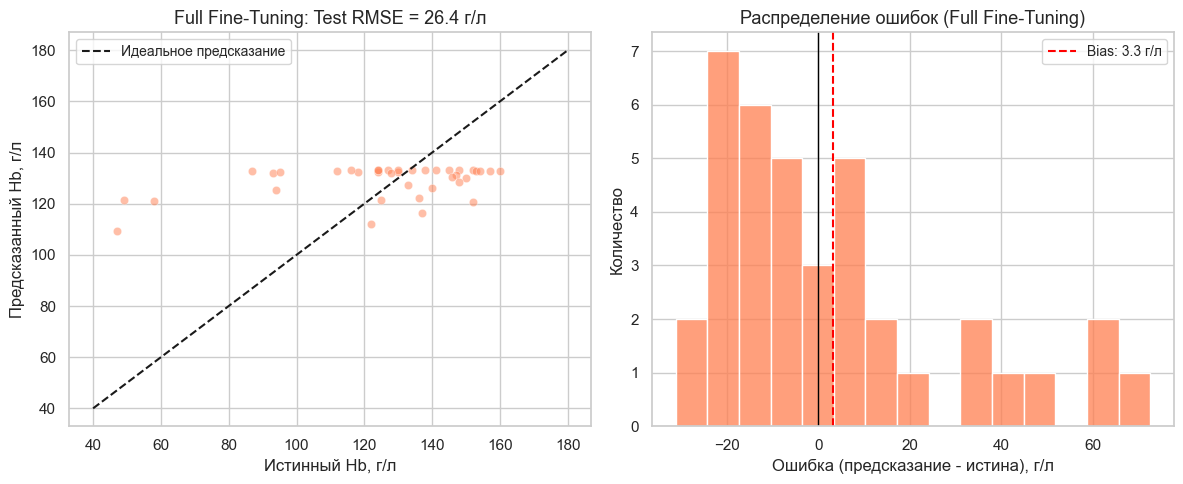

Full Fine-Tuning ResNet18 — Test RMSE: 26.4 г/л
(Frozen ResNet18 — Test RMSE: 30.2 г/л)


In [ ]:
y_pred_ft, y_true_ft = predict(model_ft, test_loader_ft)
rmse_ft = np.sqrt(np.mean((y_pred_ft - y_true_ft)**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_true_ft, y=y_pred_ft, alpha=0.5, color='coral', ax=axes[0])
axes[0].plot([40, 180], [40, 180], 'k--', label='Идеальное предсказание')
axes[0].set_xlabel('Истинный Hb, г/л', fontsize=12)
axes[0].set_ylabel('Предсказанный Hb, г/л', fontsize=12)
axes[0].set_title(f'Full Fine-Tuning: Test RMSE = {rmse_ft:.1f} г/л', fontsize=13)
axes[0].legend(fontsize=10)

sns.histplot(y_pred_ft - y_true_ft, bins=15, color='coral', edgecolor='white', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
mean_err = np.mean(y_pred_ft - y_true_ft)
axes[1].axvline(mean_err, color='red', linestyle='--',
                label=f'Bias: {mean_err:.1f} г/л')
axes[1].set_xlabel('Ошибка (предсказание - истина), г/л', fontsize=12)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].set_title('Распределение ошибок (Full Fine-Tuning)', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Full Fine-Tuning ResNet18 — Test RMSE: {rmse_ft:.1f} г/л')
print(f'(Frozen ResNet18 — Test RMSE: {rmse_test_dl:.1f} г/л)')

## 7. Сравнение подходов: ML vs DL (frozen) vs DL (fine-tuned)

Сравним три подхода:
1. **ElasticNet** (ML) — классические признаки + линейная модель
2. **ResNet18 frozen** — только голова обучена, сбалансированная выборка
3. **ResNet18 fine-tuned** — все слои обучены, стратифицированный сплит + BatchNorm

> **Примечание:** Fine-tuned модель обучалась на другом сплите (стратифицированном),
> поэтому её тестовая выборка отличается от первых двух моделей.

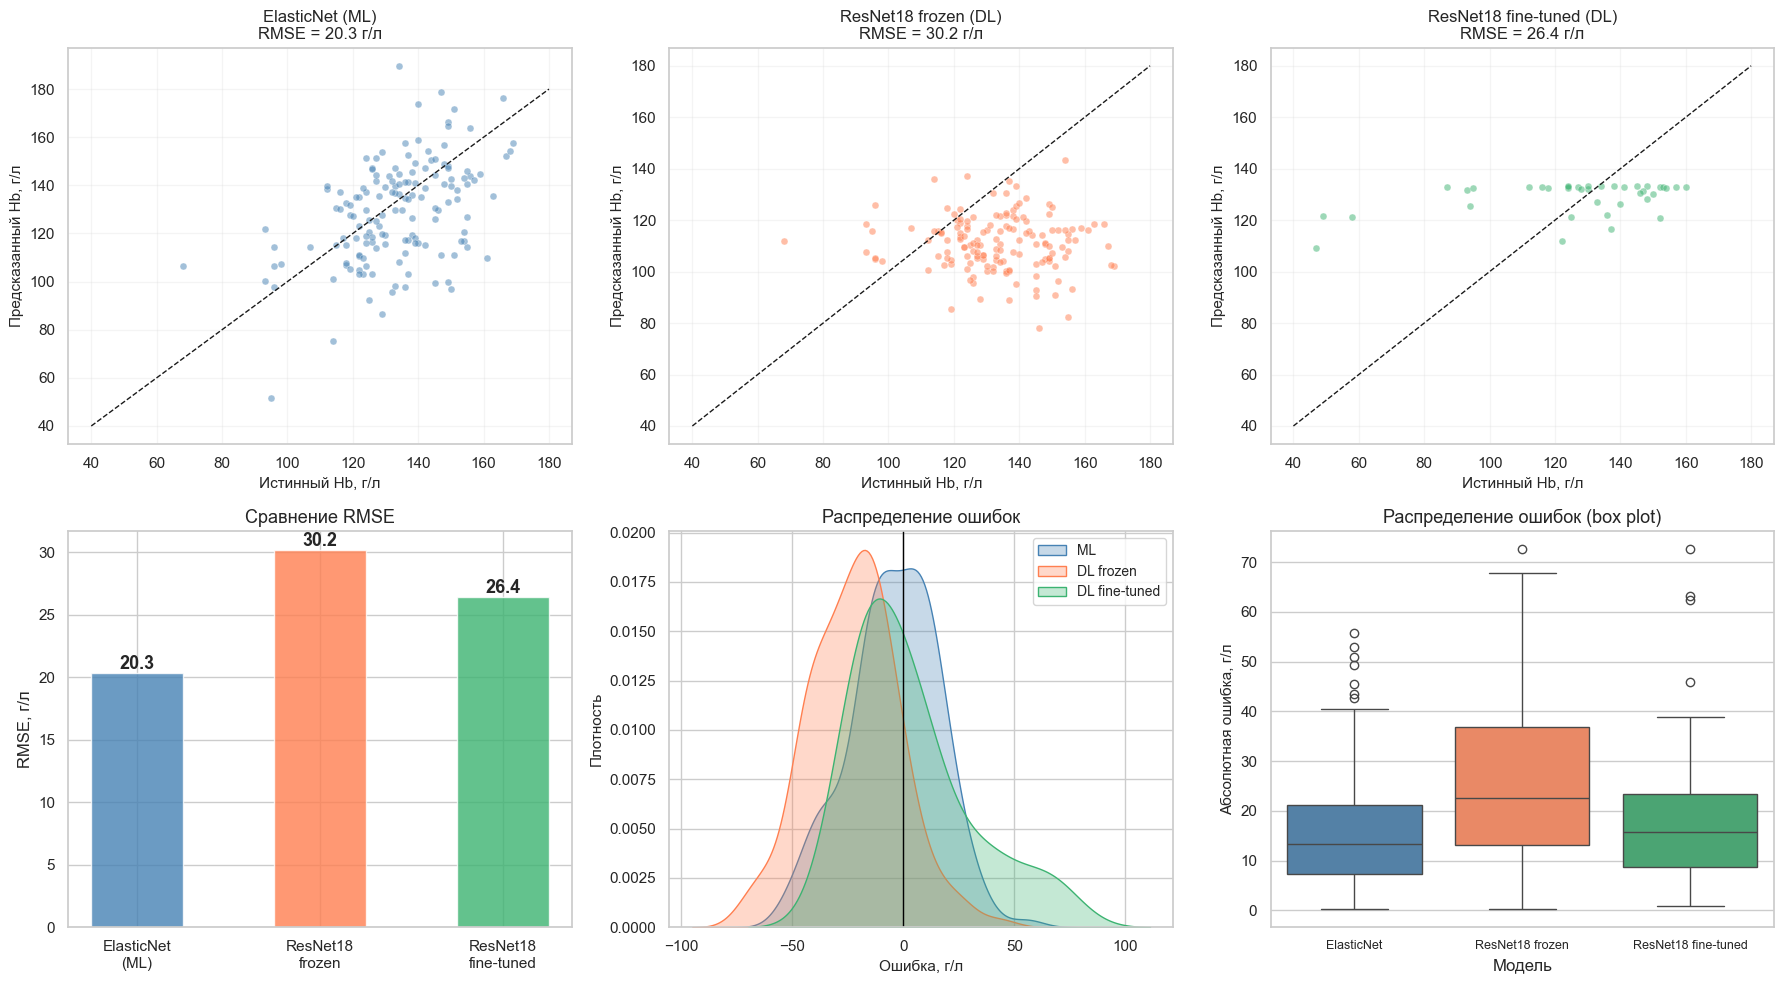


Метрика                     ElasticNet  ResNet18 frz  ResNet18 ft
Test RMSE (г/л)                   20.3          30.2         26.4
Медиана |ошибки| (г/л)            13.4          22.5         15.7
MAE (г/л)                         16.2          25.2         20.2
Bias (г/л)                        -4.3         -22.3          3.3


In [ ]:
# Fine-tuned model predictions (уже вычислены в блоке 6b)
abs_err_ml = np.abs(y_pred_test_ml - y_test_ml)
abs_err_dl = np.abs(y_pred_test_dl - y_true_test)
abs_err_ft = np.abs(y_pred_ft - y_true_ft)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Scatter plots (предсказание vs истина)
scatter_configs = [
    (axes[0,0], y_test_ml, y_pred_test_ml, 'steelblue', 'ElasticNet (ML)', rmse_test_ml),
    (axes[0,1], y_true_test, y_pred_test_dl, 'coral', 'ResNet18 frozen (DL)', rmse_test_dl),
    (axes[0,2], y_true_ft, y_pred_ft, 'mediumseagreen', 'ResNet18 fine-tuned (DL)', rmse_ft),
]
for ax, y_true, y_pred, color, name, rmse in scatter_configs:
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, color=color, s=25, ax=ax)
    ax.plot([40, 180], [40, 180], 'k--', linewidth=1)
    ax.set_xlabel('Истинный Hb, г/л', fontsize=11)
    ax.set_ylabel('Предсказанный Hb, г/л', fontsize=11)
    ax.set_title(f'{name}\nRMSE = {rmse:.1f} г/л', fontsize=12)
    ax.grid(True, alpha=0.2)

# Row 2: RMSE bar chart, error distributions, absolute error box plots
# RMSE bar chart
names = ['ElasticNet\n(ML)', 'ResNet18\nfrozen', 'ResNet18\nfine-tuned']
rmses = [rmse_test_ml, rmse_test_dl, rmse_ft]
colors = ['steelblue', 'coral', 'mediumseagreen']
bars = axes[1,0].bar(names, rmses, color=colors, alpha=0.8, width=0.5)
for bar, val in zip(bars, rmses):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}', ha='center', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('RMSE, г/л', fontsize=12)
axes[1,0].set_title('Сравнение RMSE', fontsize=13)

# Error distributions overlay
sns.kdeplot(y_pred_test_ml - y_test_ml, color='steelblue', label='ML', ax=axes[1,1], fill=True, alpha=0.3)
sns.kdeplot(y_pred_test_dl - y_true_test, color='coral', label='DL frozen', ax=axes[1,1], fill=True, alpha=0.3)
sns.kdeplot(y_pred_ft - y_true_ft, color='mediumseagreen', label='DL fine-tuned', ax=axes[1,1], fill=True, alpha=0.3)
axes[1,1].axvline(0, color='black', linewidth=1)
axes[1,1].set_xlabel('Ошибка, г/л', fontsize=11)
axes[1,1].set_ylabel('Плотность', fontsize=11)
axes[1,1].set_title('Распределение ошибок', fontsize=13)
axes[1,1].legend(fontsize=10)

# Absolute error box plots
data_for_box = pd.DataFrame({
    'Ошибка': np.concatenate([abs_err_ml, abs_err_dl, abs_err_ft]),
    'Модель': (['ElasticNet'] * len(abs_err_ml) +
               ['ResNet18 frozen'] * len(abs_err_dl) +
               ['ResNet18 fine-tuned'] * len(abs_err_ft))
})
sns.boxplot(data=data_for_box, x='Модель', y='Ошибка',
            palette=['steelblue', 'coral', 'mediumseagreen'], ax=axes[1,2])
axes[1,2].set_ylabel('Абсолютная ошибка, г/л', fontsize=11)
axes[1,2].set_title('Распределение ошибок (box plot)', fontsize=13)
axes[1,2].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"="*65}')
print(f'{"Метрика":<25} {"ElasticNet":>12} {"ResNet18 frz":>13} {"ResNet18 ft":>12}')
print(f'{"="*65}')
print(f'{"Test RMSE (г/л)":<25} {rmse_test_ml:>12.1f} {rmse_test_dl:>13.1f} {rmse_ft:>12.1f}')
print(f'{"Медиана |ошибки| (г/л)":<25} {np.median(abs_err_ml):>12.1f} {np.median(abs_err_dl):>13.1f} {np.median(abs_err_ft):>12.1f}')
print(f'{"MAE (г/л)":<25} {np.mean(abs_err_ml):>12.1f} {np.mean(abs_err_dl):>13.1f} {np.mean(abs_err_ft):>12.1f}')
ml_bias = np.mean(y_pred_test_ml - y_test_ml)
dl_bias = np.mean(y_pred_test_dl - y_true_test)
ft_bias = np.mean(y_pred_ft - y_true_ft)
print(f'{"Bias (г/л)":<25} {ml_bias:>12.1f} {dl_bias:>13.1f} {ft_bias:>12.1f}')
print(f'{"="*65}')

## 8. Бонус: Детекция анемии (классификация)

До сих пор мы решали задачу **регрессии** — предсказывали точное число (Hb в г/л).
Но в клинической практике часто важнее **классификация**: есть анемия или нет?

Переведём предсказания в бинарный формат:
- **Анемия**: Hb < 120 г/л → класс 1
- **Норма**: Hb ≥ 120 г/л → класс 0

> Мы используем порог 120 г/л — это нижняя граница нормы для женщин по ВОЗ.

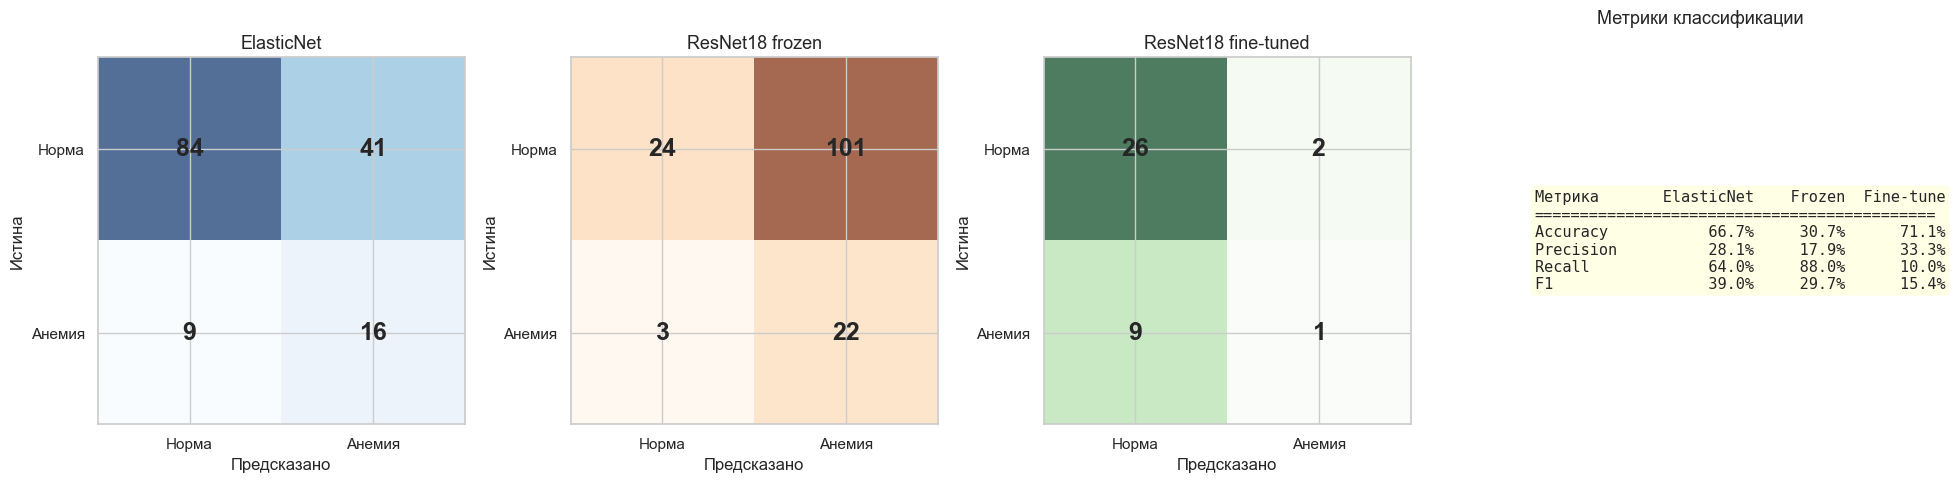

In [ ]:
threshold = 120

# ML и frozen DL — общая тестовая выборка
y_true_cls = (y_test_ml < threshold).astype(int)
y_pred_cls_ml = (y_pred_test_ml < threshold).astype(int)
y_pred_cls_dl = (y_pred_test_dl < threshold).astype(int)

# Fine-tuned DL — своя тестовая выборка (стратифицированный сплит)
y_true_cls_ft = (y_true_ft < threshold).astype(int)
y_pred_cls_ft = (y_pred_ft < threshold).astype(int)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Confusion matrices
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

configs = [
    (axes[0], y_true_cls, y_pred_cls_ml, 'ElasticNet', 'Blues'),
    (axes[1], y_true_cls, y_pred_cls_dl, 'ResNet18 frozen', 'Oranges'),
    (axes[2], y_true_cls_ft, y_pred_cls_ft, 'ResNet18 fine-tuned', 'Greens'),
]
for ax, yt, yp, name, cmap in configs:
    cm = sklearn.metrics.confusion_matrix(yt, yp)
    ax.imshow(cm, interpolation='nearest', cmap=cmap, alpha=0.7)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Норма', 'Анемия'], fontsize=11)
    ax.set_yticklabels(['Норма', 'Анемия'], fontsize=11)
    ax.set_xlabel('Предсказано', fontsize=12)
    ax.set_ylabel('Истина', fontsize=12)
    ax.set_title(name, fontsize=13)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=18, fontweight='bold')

# Summary metrics
def cls_metrics(y_true, y_pred):
    return (accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, zero_division=0),
            recall_score(y_true, y_pred, zero_division=0),
            f1_score(y_true, y_pred, zero_division=0))

m_ml = cls_metrics(y_true_cls, y_pred_cls_ml)
m_dl = cls_metrics(y_true_cls, y_pred_cls_dl)
m_ft = cls_metrics(y_true_cls_ft, y_pred_cls_ft)

header = f"{'Метрика':<12} {'ElasticNet':>11} {'Frozen':>9} {'Fine-tune':>10}"
sep = '=' * 44
lines = [header, sep]
for name, i in [('Accuracy', 0), ('Precision', 1), ('Recall', 2), ('F1', 3)]:
    lines.append(f"{name:<12} {m_ml[i]:>11.1%} {m_dl[i]:>9.1%} {m_ft[i]:>10.1%}")

metrics_text = '\n'.join(lines)
axes[3].text(0.05, 0.5, metrics_text, transform=axes[3].transAxes,
             fontsize=11, va='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[3].axis('off')
axes[3].set_title('Метрики классификации', fontsize=13)

plt.tight_layout()
plt.show()

> **Как читать confusion matrix (матрицу ошибок)?**
>
> |  | Предсказано: Норма | Предсказано: Анемия |
> |---|---|---|
> | **Истина: Норма** | True Negative (TN) | False Positive (FP) |
> | **Истина: Анемия** | False Negative (FN) | True Positive (TP) |
>
> - **Recall (чувствительность)** = TP / (TP + FN) — какую долю больных мы нашли?
> - **Precision (точность)** = TP / (TP + FP) — среди тех, кого назвали больными, сколько реально больны?
> - В медицине обычно важнее **recall** — лучше перестраховаться, чем пропустить анемию

## 9. Задания для самостоятельной работы

### Уровень 1 (базовый):
1. **Измените порог анемии** на 130 г/л (для мужчин). Как изменятся метрики классификации?
2. **Посмотрите на худшие предсказания.** Для каких пациентов модель ошибается больше всего? Есть ли закономерность?

### Уровень 2 (продвинутый):
3. **Используйте все 3 ногтя** вместо среднего пальца. Усредните предсказания. Улучшится ли RMSE?
4. **Замените ResNet18 на EfficientNet-B0** (`models.efficientnet_b0`). Сравните результаты.
5. **Обучите CNN на всех 250 изображениях** (без выделения сбалансированной подвыборки).

### Уровень 3 (исследовательский):
6. **Реализуйте Grad-CAM** для визуализации областей, на которые «смотрит» нейросеть.
7. **Обучите модель для прямой классификации** (анемия/норма) с BCELoss вместо MSELoss.
8. **Комбинируйте ML и DL**: используйте признаки из CNN как входы для ElasticNet (feature extraction).

## 10. Выводы

### Что мы сделали:
1. Загрузили и исследовали датасет из 250 фотографий рук с измеренным уровнем Hb
2. Извлекли числовые признаки (перцентили RGB) и обучили классическую линейную модель
3. Применили Transfer Learning с ResNet18 для предсказания Hb по изображению ногтя
4. Сравнили оба подхода и оценили их клиническую применимость

### Ключевые выводы:

| Аспект | Классический ML | Deep Learning |
|--------|----------------|---------------|
| Признаки | Ручные (перцентили RGB) | Автоматические (CNN) |
| Интерпретируемость | Высокая | Низкая (чёрный ящик) |
| Требования к данным | Малые | Большие |
| Вычисления | CPU, секунды | GPU, минуты |
| Масштабируемость | Ограничена | Высокая |

### Клиническая значимость:
- RMSE ~20 г/л — **пока недостаточно** для точной клинической диагностики
- Но метод перспективен для **скрининга** в регионах с ограниченным доступом к лабораториям
- С увеличением датасета (тысячи пациентов) точность DL может существенно вырасти

### Ссылки:
1. [Yakimov et al. Dataset of human skin and fingernails images. Scientific Data, 2024](https://www.nature.com/articles/s41597-024-03895-9)
2. [GitHub: biophotonics-msu/photo-haemoglobin](https://github.com/biophotonics-msu/photo-haemoglobin)
3. [Figshare Dataset](https://doi.org/10.6084/m9.figshare.c.6760179)
4. [CNN Backbones for Hemoglobin Estimation (OpenReview)](https://openreview.net/forum?id=FEg5MG6l54)
5. [Machine vision model using nail images for anemia detection (Frontiers, 2025)](https://www.frontiersin.org/journals/big-data/articles/10.3389/fdata.2025.1557600/full)